You can open a `.txt` file as a pandas DataFrame using `pd.read_csv()`. This function is very versatile and can handle various delimited text files, not just `.csv` files.

You**You'll need to specify the path to your `.txt` file and, importantly, the `delimiter` (also known as `sep`).** Common delimiters include commas (`,`), tabs (`\t`), or spaces (` `).

In [5]:
import pandas as pd

# --- Configuration for your .txt file ---
file_path = '//content/GSE267287_PCOS_MPC_readcount_table.txt.gz'  # <--- IMPORTANT: Replace with the actual path to your .txt file
delimiter = '\t'                     # <--- IMPORTANT: Change this if your file is not comma-separated
                                    # For tab-separated, use '\t'
                                    # For space-separated, use ' '

try:
    # Read the .txt file into a pandas DataFrame
    df_txt = pd.read_csv(file_path, delimiter=delimiter)

    print(f"Successfully loaded '{file_path}' into a DataFrame!")
    print("Here are the first 5 rows:")
    display(df_txt.head())

    print("\nDataFrame Info:")
    df_txt.info()

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    print("Please check if the 'delimiter' is correct for your .txt file.")

Successfully loaded '//content/GSE267287_PCOS_MPC_readcount_table.txt.gz' into a DataFrame!
Here are the first 5 rows:


,0,N11311_13,N11311_14,N11311_15,N11311_16,N11311_03,N11311_04,N11311_05,N11311_07,N11311_08,N11311_09,N11311_10,N11311_11,N11311_17,N11311_18
0,ENSG00000223972.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53,26,41,18,40,32,42,58
2,ENSG00000278267.1,4,3,6,16,10,8,13,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   0          60715 non-null  object
 1   N11311_13  60715 non-null  int64 
 2   N11311_14  60715 non-null  int64 
 3   N11311_15  60715 non-null  int64 
 4   N11311_16  60715 non-null  int64 
 5   N11311_03  60715 non-null  int64 
 6   N11311_04  60715 non-null  int64 
 7   N11311_05  60715 non-null  int64 
 8   N11311_07  60715 non-null  int64 
 9   N11311_08  60715 non-null  int64 
 10  N11311_09  60715 non-null  int64 
 11  N11311_10  60715 non-null  int64 
 12  N11311_11  60715 non-null  int64 
 13  N11311_17  60715 non-null  int64 
 14  N11311_18  60715 non-null  int64 
dtypes: int64(14), object(1)
memory usage: 6.9+ MB


Based on your request, I will map the sample columns to the provided descriptive names. I will create a mapping dictionary and then use the `rename()` method to update the column names.

In [6]:
# Extract the current sample column names from df_txt (excluding the first column '0')
current_sample_columns = df_txt.columns[1:].tolist()

# The descriptive names provided by the user (in order)
new_sample_names = [
    'C25',
    'C25 w/ testosterone',
    'C24',
    'C24 w/ testosterone',
    'C31',
    'C31 w/ testosterone',
    'C32',
    'P2',
    'P2 w/ testosterone',
    'P5',
    'P5 w/ testosterone',
    'P11',
    'P12',
    'P12 w/ testosterone'
]

# Create a mapping dictionary
# We check to ensure the number of columns matches the number of new names
if len(current_sample_columns) == len(new_sample_names):
    column_rename_map = dict(zip(current_sample_columns, new_sample_names))

    # Rename the columns in the DataFrame
    df_txt_renamed = df_txt.rename(columns=column_rename_map)

    print("Successfully renamed the sample columns. Here are the first 5 rows with new names:")
    display(df_txt_renamed.head())

    print("\nUpdated DataFrame Info:")
    df_txt_renamed.info()

    # Update df_txt to the renamed DataFrame for subsequent operations
    df_txt = df_txt_renamed

else:
    print(f"Error: Number of existing sample columns ({len(current_sample_columns)}) does not match the number of provided new names ({len(new_sample_names)}).")
    print("Please ensure the lists are of equal length for accurate mapping.")

Successfully renamed the sample columns. Here are the first 5 rows with new names:


,0,C25,C25 w/ testosterone,C24,C24 w/ testosterone,C31,C31 w/ testosterone,C32,P2,P2 w/ testosterone,P5,P5 w/ testosterone,P11,P12,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53,26,41,18,40,32,42,58
2,ENSG00000278267.1,4,3,6,16,10,8,13,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25                  60715 non-null  int64 
 2   C25 w/ testosterone  60715 non-null  int64 
 3   C24                  60715 non-null  int64 
 4   C24 w/ testosterone  60715 non-null  int64 
 5   C31                  60715 non-null  int64 
 6   C31 w/ testosterone  60715 non-null  int64 
 7   C32                  60715 non-null  int64 
 8   P2                   60715 non-null  int64 
 9   P2 w/ testosterone   60715 non-null  int64 
 10  P5                   60715 non-null  int64 
 11  P5 w/ testosterone   60715 non-null  int64 
 12  P11                  60715 non-null  int64 
 13  P12                  60715 non-null  int64 
 14  P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(14), object(1)
memo

To separate the DataFrame into controls and PCOS samples, I'll identify columns that start with 'C' as control samples and columns that start with 'P' as PCOS samples. The first column, which likely contains gene or feature identifiers, will be included in both new DataFrames for context.

In [7]:
# Assuming the first column (index 0) contains identifiers and should be kept in both dataframes
identifier_column = df_txt.columns[0]

# Initialize lists to hold control and PCOS column names, including the identifier column
control_columns = [identifier_column]
PCOS_columns = [identifier_column]

# Iterate through the rest of the columns to categorize them
for col in df_txt.columns[1:]:
    if col.startswith('C'):
        control_columns.append(col)
    elif col.startswith('P'):
        PCOS_columns.append(col)

# Create the new DataFrames
df_control = df_txt[control_columns].copy()
df_PCOS = df_txt[PCOS_columns].copy()

print("DataFrame for Control samples (first 5 rows):")
display(df_control.head())
print("\nControl DataFrame Info:")
df_control.info()

print("\nDataFrame for PCOS samples (first 5 rows):")
display(df_PCOS.head())
print("\nPCOS DataFrame Info:")
df_PCOS.info()

DataFrame for Control samples (first 5 rows):


,0,C25,C25 w/ testosterone,C24,C24 w/ testosterone,C31,C31 w/ testosterone,C32
0,ENSG00000223972.5,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53
2,ENSG00000278267.1,4,3,6,16,10,8,13
3,ENSG00000243485.5,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0



Control DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25                  60715 non-null  int64 
 2   C25 w/ testosterone  60715 non-null  int64 
 3   C24                  60715 non-null  int64 
 4   C24 w/ testosterone  60715 non-null  int64 
 5   C31                  60715 non-null  int64 
 6   C31 w/ testosterone  60715 non-null  int64 
 7   C32                  60715 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.7+ MB

DataFrame for PCOS samples (first 5 rows):


,0,P2,P2 w/ testosterone,P5,P5 w/ testosterone,P11,P12,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0,0,0,0,0
1,ENSG00000227232.5,26,41,18,40,32,42,58
2,ENSG00000278267.1,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0



PCOS DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   P2                   60715 non-null  int64 
 2   P2 w/ testosterone   60715 non-null  int64 
 3   P5                   60715 non-null  int64 
 4   P5 w/ testosterone   60715 non-null  int64 
 5   P11                  60715 non-null  int64 
 6   P12                  60715 non-null  int64 
 7   P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.7+ MB


To further refine our datasets, I will now separate the `df_control` and `df_PCOS` DataFrames into four distinct groups:

1.  **Control (without testosterone)**: Samples from the control group that did not receive testosterone.
2.  **Control (with testosterone)**: Samples from the control group that received testosterone.
3.  **PCOS (without testosterone)**: Samples from the PCOS group that did not receive testosterone.
4.  **PCOS (with testosterone)**: Samples from the PCOS group that received testosterone.

I will ensure the identifier column is included in all new DataFrames for context.

In [8]:
# Assuming the first column (identifier_column) is '0'
identifier_column = df_control.columns[0]

# --- Separate Control Samples ---
control_no_testosterone_columns = [identifier_column]
control_w_testosterone_columns = [identifier_column]

for col in df_control.columns[1:]:
    if 'w/ testosterone' in col:
        control_w_testosterone_columns.append(col)
    else:
        control_no_testosterone_columns.append(col)

df_control_no_testosterone = df_control[control_no_testosterone_columns].copy()
df_control_w_testosterone = df_control[control_w_testosterone_columns].copy()

print("DataFrame for Control samples (without testosterone, first 5 rows):")
display(df_control_no_testosterone.head())
print("\nControl (without testosterone) DataFrame Info:")
df_control_no_testosterone.info()

print("\nDataFrame for Control samples (with testosterone, first 5 rows):")
display(df_control_w_testosterone.head())
print("\nControl (with testosterone) DataFrame Info:")
df_control_w_testosterone.info()

# --- Separate PCOS Samples ---
PCOS_no_testosterone_columns = [identifier_column]
PCOS_w_testosterone_columns = [identifier_column]

for col in df_PCOS.columns[1:]:
    if 'w/ testosterone' in col:
        PCOS_w_testosterone_columns.append(col)
    else:
        PCOS_no_testosterone_columns.append(col)

df_PCOS_no_testosterone = df_PCOS[PCOS_no_testosterone_columns].copy()
df_PCOS_w_testosterone = df_PCOS[PCOS_w_testosterone_columns].copy()

print("\nDataFrame for PCOS samples (without testosterone, first 5 rows):")
display(df_PCOS_no_testosterone.head())
print("\nPCOS (without testosterone) DataFrame Info:")
df_PCOS_no_testosterone.info()

print("\nDataFrame for PCOS samples (with testosterone, first 5 rows):")
display(df_PCOS_w_testosterone.head())
print("\nPCOS (with testosterone) DataFrame Info:")
df_PCOS_w_testosterone.info()

DataFrame for Control samples (without testosterone, first 5 rows):


,0,C25,C24,C31,C32
0,ENSG00000223972.5,0,0,0,0
1,ENSG00000227232.5,42,39,44,53
2,ENSG00000278267.1,4,6,10,13
3,ENSG00000243485.5,0,0,0,0
4,ENSG00000284332.1,0,0,0,0



Control (without testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       60715 non-null  object
 1   C25     60715 non-null  int64 
 2   C24     60715 non-null  int64 
 3   C31     60715 non-null  int64 
 4   C32     60715 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 2.3+ MB

DataFrame for Control samples (with testosterone, first 5 rows):


,0,C25 w/ testosterone,C24 w/ testosterone,C31 w/ testosterone
0,ENSG00000223972.5,0,0,0
1,ENSG00000227232.5,52,75,65
2,ENSG00000278267.1,3,16,8
3,ENSG00000243485.5,0,0,0
4,ENSG00000284332.1,0,0,0



Control (with testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25 w/ testosterone  60715 non-null  int64 
 2   C24 w/ testosterone  60715 non-null  int64 
 3   C31 w/ testosterone  60715 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.9+ MB

DataFrame for PCOS samples (without testosterone, first 5 rows):


,0,P2,P5,P11,P12
0,ENSG00000223972.5,0,0,0,0
1,ENSG00000227232.5,26,18,32,42
2,ENSG00000278267.1,1,2,8,7
3,ENSG00000243485.5,0,0,0,0
4,ENSG00000284332.1,0,0,0,0



PCOS (without testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       60715 non-null  object
 1   P2      60715 non-null  int64 
 2   P5      60715 non-null  int64 
 3   P11     60715 non-null  int64 
 4   P12     60715 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 2.3+ MB

DataFrame for PCOS samples (with testosterone, first 5 rows):


,0,P2 w/ testosterone,P5 w/ testosterone,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0
1,ENSG00000227232.5,41,40,58
2,ENSG00000278267.1,22,17,6
3,ENSG00000243485.5,0,0,0
4,ENSG00000284332.1,0,0,0



PCOS (with testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   P2 w/ testosterone   60715 non-null  int64 
 2   P5 w/ testosterone   60715 non-null  int64 
 3   P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.9+ MB


A volcano plot is a type of scatter plot that is used to visualize differential expression data. It plots the negative logarithm of the p-value (or adjusted p-value) on the y-axis and the log2 fold change on the x-axis. This allows for quick visual identification of genes that are both statistically significant and have a large magnitude of change.

First, I'll install the `pydeseq2` library, which is necessary for differential gene expression analysis. This might take a moment.

In [9]:
!pip install pydeseq2 -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 10.7 MB/s eta 0:00:00


Now that `pydeseq2` is installed, I need to prepare the data in the format required by the library. This involves:

1.  **Creating a `counts_df`**: A DataFrame containing raw gene counts, with gene identifiers as the index and sample names as columns.
2.  **Creating a `clinical_df`**: A DataFrame containing metadata for each sample, with sample names as the index and a column indicating the experimental condition (e.g., 'control' or 'PCOS').

I will combine `df_control_no_testosterone` and `df_PCOS_no_testosterone` to create these inputs.

In [10]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

# Assuming the identifier column is '0'
identifier_column = '0'

# --- Prepare counts_df ---
# Set the identifier column as index for both dataframes
df_control_no_testosterone_indexed = df_control_no_testosterone.set_index(identifier_column)
df_PCOS_no_testosterone_indexed = df_PCOS_no_testosterone.set_index(identifier_column)

# Concatenate the dataframes to form the counts_df
# Ensure columns are only count data (excluding the identifier column)
counts_df = pd.concat([
    df_control_no_testosterone_indexed.drop(columns=[], errors='ignore'),
    df_PCOS_no_testosterone_indexed.drop(columns=[], errors='ignore')
], axis=1)

# Transpose counts_df so samples are rows and genes are columns
counts_df = counts_df.T

# Ensure all counts are integers
counts_df = counts_df.astype(int)

print("Counts DataFrame (first 5 rows):")
display(counts_df.head())
print("\nCounts DataFrame Info:")
counts_df.info()

# --- Prepare clinical_df ---
sample_names = counts_df.index.tolist() # Changed to use the index (samples) of the transposed counts_df

# Create a list of conditions based on sample names
conditions = []
for sample in sample_names:
    if sample.startswith('C'):
        conditions.append('control')
    elif sample.startswith('P'):
        conditions.append('PCOS')
    else:
        conditions.append('unknown') # Should not happen with current data

clinical_df = pd.DataFrame({
    'condition': conditions
}, index=sample_names)

print("\nClinical DataFrame:")
display(clinical_df)
print("\nClinical DataFrame Info:")
clinical_df.info()

Counts DataFrame (first 5 rows):


0,ENSG00000223972.5,ENSG00000227232.5,ENSG00000278267.1,ENSG00000243485.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.6,ENSG00000238009.6,...,ENSG00000273739.1,ENSG00000276700.1,ENSG00000276312.1,ENSG00000275757.1,ENSG00000278573.1,ENSG00000276017.1,ENSG00000278817.1,ENSG00000277196.4,ENSG00000278625.1,ENSG00000277374.1
C25,0,42,4,0,0,0,0,0,0,8,...,0,1,0,0,0,0,16,2,0,0
C24,0,39,6,0,0,0,0,0,0,14,...,0,4,0,1,0,0,8,13,0,0
C31,0,44,10,0,0,0,0,0,0,3,...,0,1,0,0,0,0,8,30,0,0
C32,0,53,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,31,51,0,0
P2,0,26,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,23,43,0,0



Counts DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, C25 to P12
Columns: 60715 entries, ENSG00000223972.5 to ENSG00000277374.1
dtypes: int64(60715)
memory usage: 3.7+ MB

Clinical DataFrame:


,condition
C25,control
C24,control
C31,control
C32,control
P2,PCOS
P5,PCOS
P11,PCOS
P12,PCOS



Clinical DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, C25 to P12
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   condition  8 non-null      object
dtypes: object(1)
memory usage: 428.0+ bytes


With the `counts_df` and `clinical_df` prepared, I can now run the DESeq2 analysis. This will involve creating a `DeseqDataSet` object and then performing the differential expression testing using `DeseqStats`.

In [11]:
# Create a DeseqDataSet object
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors=['condition'],
    refit_cooks=True,
    inference=DefaultInference(n_cpus=8) # Use multiple CPUs for faster computation if available
)

# Run the DESeq2 pipeline
dds.deseq2()

# Perform differential expression testing
# Comparing 'PCOS' condition against the 'control' condition (which is the reference level by default)
stat_res = DeseqStats(dds, contrast=['condition', 'PCOS', 'control'])
stat_res.summary()

# Get the results DataFrame
differential_expression_results = stat_res.results_df

print("Differential Expression Analysis Results (first 10 rows, sorted by p-value):")
# Sort by adjusted p-value to see the most significant genes first
display(differential_expression_results.sort_values('padj').head(10))

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_12404/2163048366.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 33.22 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.62 seconds.

Fitting MAP dispersions...
... done in 50.65 seconds.

Fitting LFCs...
... done in 28.49 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 14.33 seconds.



Log2 fold change & Wald test p-value: condition PCOS vs control
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0                                                                            
ENSG00000223972.5   0.000000             NaN       NaN       NaN       NaN   
ENSG00000227232.5  35.801703       -0.468821  0.253536 -1.849129  0.064439   
ENSG00000278267.1   6.057065       -0.798238  0.693106 -1.151683  0.249451   
ENSG00000243485.5   0.000000             NaN       NaN       NaN       NaN   
ENSG00000284332.1   0.000000             NaN       NaN       NaN       NaN   
...                      ...             ...       ...       ...       ...   
ENSG00000276017.1   0.000000             NaN       NaN       NaN       NaN   
ENSG00000278817.1  17.025742        0.454117  0.611006  0.743228  0.457344   
ENSG00000277196.4  21.819364       -0.114344  1.077765 -0.106094  0.915508   
ENSG00000278625.1   0.000000             NaN       NaN       NaN       NaN   


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,,,,,,
ENSG00000213058.3,99.189157,-5.762764,0.516882,-11.149089,7.234352e-29,1.320993e-24
ENSG00000214455.4,359.752208,1.532459,0.178633,8.578802,9.586651e-18,8.752613e-14
ENSG00000160221.18,39.511545,3.805188,0.584216,6.513327,7.350449e-11,4.473973e-07
ENSG00000147044.22,3064.329843,-1.207982,0.219002,-5.515844,3.471110e-08,7.822680e-05
ENSG00000114948.13,1355.867224,1.377594,0.249391,5.523832,3.316844e-08,7.822680e-05
ENSG00000239528.1,10.580014,-4.346204,0.776923,-5.594126,2.217364e-08,7.822680e-05
ENSG00000203952.9,46.057753,-1.473164,0.264113,-5.577771,2.436205e-08,7.822680e-05
ENSG00000204991.11,85.177060,0.999740,0.181859,5.497339,3.855648e-08,7.822680e-05
ENSG00000224114.1,113.825111,-2.237788,0.403004,-5.552772,2.811744e-08,7.822680e-05


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make a copy to avoid modifying the original DataFrame and drop NaNs
plot_df = differential_expression_results.copy().dropna(subset=['log2FoldChange', 'padj'])

# Define significance thresholds
log2fc_threshold = 0.5  # Absolute log2 fold change threshold
p_adj_threshold = 0.05  # Adjusted p-value threshold

# Add a column for -log10(padj)
plot_df['-log10(padj)'] = -np.log10(plot_df['padj'])

# Categorize genes based on significance and fold change
plot_df['significance'] = 'Not significant'
plot_df.loc[(plot_df['log2FoldChange'] > log2fc_threshold) & (plot_df['padj'] < p_adj_threshold), 'significance'] = 'Upregulated'
plot_df.loc[(plot_df['log2FoldChange'] < -log2fc_threshold) & (plot_df['padj'] < p_adj_threshold), 'significance'] = 'Downregulated'



In [13]:
# Filter for differentially expressed genes (Upregulated or Downregulated)
differentially_expressed_genes = plot_df[plot_df['significance'] != 'Not significant'].copy()
# Display the gene IDs, log2FoldChange, padj, and significance category
print(f"Total differentially expressed genes: {len(differentially_expressed_genes)}")
display(differentially_expressed_genes[['log2FoldChange', 'padj', 'significance']].sort_values('padj').head(20)) # Display top 20 by adjusted p-value

# You can also display all of them if needed:
# display(differentially_expressed_genes[['log2FoldChange', 'padj', 'significance']].sort_values('padj'))

Total differentially expressed genes: 86


,log2FoldChange,padj,significance
0,,,
ENSG00000213058.3,-5.762764,1.320993e-24,Downregulated
ENSG00000214455.4,1.532459,8.752613e-14,Upregulated
ENSG00000160221.18,3.805188,4.473973e-07,Upregulated
ENSG00000114948.13,1.377594,7.822680e-05,Upregulated
ENSG00000239528.1,-4.346204,7.822680e-05,Downregulated
ENSG00000203952.9,-1.473164,7.822680e-05,Downregulated
ENSG00000204991.11,0.999740,7.822680e-05,Upregulated
ENSG00000224114.1,-2.237788,7.822680e-05,Downregulated
ENSG00000147044.22,-1.207982,7.822680e-05,Downregulated


## Install Gene Annotation Library

### Subtask:
Install a Python-based library like `mygene` to query gene annotation databases and retrieve gene symbols for the Ensembl IDs. This eliminates the need for R and Bioconductor.


**Reasoning**:
The subtask requires installing the `mygene` library. This command will install the necessary library.



In [14]:
print("Installing mygene library...")
!pip install mygene -qq
print("mygene library installed.")

Installing mygene library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
mygene library installed.


## Retrieve Gene Symbols

### Subtask:
Extract the Ensembl IDs from the `differentially_expressed_genes` DataFrame and use the `mygene` library to query gene symbols for these IDs. Handle cases where a symbol might not be found or multiple symbols are returned.


**Reasoning**:
First, I need to import the `mygene` library and instantiate a `MyGeneInfo` object to prepare for querying gene annotation databases.



In [15]:
import mygene

# Instantiate a MyGeneInfo client
mg = mygene.MyGeneInfo()

print("mygene library imported and MyGeneInfo client instantiated.")

mygene library imported and MyGeneInfo client instantiated.


**Reasoning**:
Now that the `MyGeneInfo` client is instantiated, I will extract the Ensembl IDs from the index of the `differentially_expressed_genes` DataFrame and query `mygene` for their corresponding gene symbols, handling cases where a symbol might not be found or multiple symbols are returned.



**Reasoning**:
Now that gene symbols have been successfully retrieved and added to the `differentially_expressed_genes` DataFrame, I will prepare the data for plotting by selecting the most significant genes to label, and then generate a volcano plot that includes these gene symbols as labels, making the visualization more informative.



In [16]:
import pandas as pd
import mygene

# Instantiate a MyGeneInfo client (ensure it's instantiated if not already global)
mg = mygene.MyGeneInfo()

# 1. Extract the Ensembl IDs from the index of the differentially_expressed_genes DataFrame
versioned_ensembl_ids = differentially_expressed_genes.index.tolist()

# Create a list of unversioned Ensembl IDs for querying
unversioned_ensembl_ids = [id.split('.')[0] for id in versioned_ensembl_ids]

print(f"Found {len(unversioned_ensembl_ids)} unversioned Ensembl IDs to query.")

# 2. Use the mg.querymany method to query for gene symbols
# This function is specifically designed for batch queries and returns a list of results.
query_results = mg.querymany(
    unversioned_ensembl_ids, # Query with unversioned IDs
    scopes='ensembl.gene',
    fields='symbol',
    species='human',
    as_dataframe=False
)

# 3. Iterate through the query results and extract the gene symbols
# This map will store unversioned_ensembl_id -> symbol
unversioned_gene_symbol_map = {}

# querymany returns a list of dictionaries, one for each queried ID
for res in query_results:
    ensembl_id = res.get('query') # This will be the unversioned ID
    symbol = None
    if ensembl_id:
        # Check if there are 'hits' for this query
        if res.get('symbol'): # mygene.querymany directly puts the symbol at the top level if found
            symbol = res['symbol']
        elif res.get('alias'): # Fallback to alias
            symbol = res['alias']

    unversioned_gene_symbol_map[ensembl_id] = symbol


print("\nFirst 10 entries of the unversioned Ensembl ID to Gene Symbol mapping:")
# Display first 10 items of the dictionary
for i, (ensembl, symbol) in enumerate(unversioned_gene_symbol_map.items()):
    if i >= 10:
        break
    print(f"{ensembl}: {symbol}")

# Add the gene symbols to the differentially_expressed_genes DataFrame
# The DataFrame index contains versioned IDs, so we need to strip the version to lookup in unversioned_gene_symbol_map
differentially_expressed_genes['GeneSymbol'] = differentially_expressed_genes.index.map(
    lambda x: unversioned_gene_symbol_map.get(x.split('.')[0])
)

print("\nDifferentially expressed genes with new 'GeneSymbol' column (first 5 rows):")
display(differentially_expressed_genes)

INFO:biothings.client:querying 1-86 ...


Found 86 unversioned Ensembl IDs to query.


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.



First 10 entries of the unversioned Ensembl ID to Gene Symbol mapping:
ENSG00000215790: SLC35E2A
ENSG00000158055: GRHL3
ENSG00000178965: ERICH3
ENSG00000171488: LRRC8C
ENSG00000233593: LINC02609
ENSG00000007341: ST7L
ENSG00000277147: LINC00869
ENSG00000143603: KCNN3
ENSG00000213058: None
ENSG00000224114: RPS14P1

Differentially expressed genes with new 'GeneSymbol' column (first 5 rows):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol
0,,,,,,,,,
ENSG00000215790.7,384.955023,1.122125,0.281557,3.985422,6.736036e-05,0.018358,1.736170,Upregulated,SLC35E2A
ENSG00000158055.16,29.956322,-2.894274,0.573072,-5.050454,4.407623e-07,0.000402,3.395325,Downregulated,GRHL3
ENSG00000178965.14,6.376822,-4.002659,1.052922,-3.801477,1.438362e-04,0.033246,1.478258,Downregulated,ERICH3
ENSG00000171488.15,382.254173,-1.687147,0.430737,-3.916884,8.970097e-05,0.023070,1.636960,Downregulated,LRRC8C
ENSG00000233593.10,41.195160,2.344547,0.564841,4.150808,3.313037e-05,0.012099,1.917243,Upregulated,LINC02609
...,...,...,...,...,...,...,...,...,...
ENSG00000133142.17,4054.153412,-1.011176,0.203321,-4.973292,6.582542e-07,0.000572,3.242325,Downregulated,TCEAL4
ENSG00000157502.13,35.611932,4.642353,1.098882,4.224616,2.393487e-05,0.009933,2.002921,Upregulated,PWWP3B
ENSG00000089682.16,565.498280,-1.102092,0.274826,-4.010152,6.067979e-05,0.017046,1.768369,Downregulated,RBM41


## Methods for Differential Gene Expression Analysis and Volcano Plot Generation

Differential gene expression analysis was conducted using the `pydeseq2` library, an adaptation of the DESeq2 method for Python, which is specifically designed for RNA-seq count data. Initially, raw gene counts from control and PCOS samples (without testosterone treatment) were prepared into a `counts_df` DataFrame, with gene identifiers as the index and sample names as columns. Concurrently, a `clinical_df` DataFrame was created to hold sample metadata, mapping each sample to its respective condition ('control' or 'PCOS').

A `DeseqDataSet` object was then constructed using these DataFrames, and the `pydeseq2` pipeline was executed to normalize counts, estimate dispersions, and fit log2 fold changes. Differential expression testing was performed using a Wald test, comparing the 'PCOS' condition against the 'control' condition. The results, including base mean expression, log2 fold change, standard error, test statistic, p-value, and adjusted p-value (`padj`), were compiled into a `differential_expression_results` DataFrame.

To enhance interpretability, gene symbols were retrieved for the Ensembl IDs within the differentially expressed gene set. The `mygene` library's `querymany` function was employed, after stripping version numbers from the Ensembl IDs to improve query success. The retrieved gene symbols were then integrated into the `differentially_expressed_genes` DataFrame.

Finally, a volcano plot was generated to visually represent the differential expression. Genes were categorized as 'Upregulated' (log2 fold change > 0.5 and `padj` < 0.05), 'Downregulated' (log2 fold change < -0.5 and `padj` < 0.05), or 'Not significant'. The plot displays log2 fold change on the x-axis and the negative logarithm of the adjusted p-value on the y-axis. Significance thresholds were marked with dashed lines. To highlight key findings, the top 20 most differentially expressed genes (based on their adjusted p-value) were labeled on the plot using their gene symbols, with an increased font size for improved readability.

In [17]:
print("Top 20 differentially expressed genes (sorted by adjusted p-value):")
display(differentially_expressed_genes[['GeneSymbol', 'log2FoldChange', 'padj', 'significance']].sort_values('padj').head(86))

Top 20 differentially expressed genes (sorted by adjusted p-value):


,GeneSymbol,log2FoldChange,padj,significance
0,,,,
ENSG00000213058.3,None,-5.762764,1.320993e-24,Downregulated
ENSG00000214455.4,RCN1P2,1.532459,8.752613e-14,Upregulated
ENSG00000160221.18,GATD3,3.805188,4.473973e-07,Upregulated
ENSG00000114948.13,ADAM23,1.377594,7.822680e-05,Upregulated
ENSG00000239528.1,RPS14P8,-4.346204,7.822680e-05,Downregulated
...,...,...,...,...
ENSG00000143603.19,KCNN3,-1.349730,4.846000e-02,Downregulated
ENSG00000003436.16,TFPI,1.387254,4.873939e-02,Upregulated
ENSG00000145569.6,OTULINL,2.253578,4.873939e-02,Upregulated


## Export Differentially Expressed Genes to CSV

### Subtask:
Export the `differentially_expressed_genes` DataFrame, which contains the 86 genes and their associated information, to a CSV file.


In [18]:
import pandas as pd

# 1. Reset the index of the differentially_expressed_genes DataFrame
df_to_export = differentially_expressed_genes.reset_index()

# Rename the index column to 'EnsemblID' for clarity
df_to_export = df_to_export.rename(columns={'index': 'EnsemblID'})

# 2. Export the df_to_export DataFrame to a CSV file
output_filename = 'differentially_expressed_genes.csv'
df_to_export.to_csv(output_filename, index=False)

print(f"Successfully exported differentially expressed genes to '{output_filename}'")
print("Here are the first 5 rows of the exported DataFrame:")
display(df_to_export.head())

Successfully exported differentially expressed genes to 'differentially_expressed_genes.csv'
Here are the first 5 rows of the exported DataFrame:


,0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol
0,ENSG00000215790.7,384.955023,1.122125,0.281557,3.985422,6.736036e-05,0.018358,1.736170,Upregulated,SLC35E2A
1,ENSG00000158055.16,29.956322,-2.894274,0.573072,-5.050454,4.407623e-07,0.000402,3.395325,Downregulated,GRHL3
2,ENSG00000178965.14,6.376822,-4.002659,1.052922,-3.801477,1.438362e-04,0.033246,1.478258,Downregulated,ERICH3
3,ENSG00000171488.15,382.254173,-1.687147,0.430737,-3.916884,8.970097e-05,0.023070,1.636960,Downregulated,LRRC8C
4,ENSG00000233593.10,41.195160,2.344547,0.564841,4.150808,3.313037e-05,0.012099,1.917243,Upregulated,LINC02609


## Prepare Data for Labeled Volcano Plot

### Subtask:
Create a new DataFrame for plotting by taking the `differentially_expressed_genes` DataFrame, ensuring it includes all necessary columns like `log2FoldChange`, `padj`, `-log10(padj)`, `significance`, and `GeneSymbol`. Then, identify the top 20 most differentially expressed genes based on their adjusted p-value for labeling.


In [19]:
import numpy as np

# 1. Start with the differentially_expressed_genes DataFrame, which already has GeneSymbol
# Make a copy to avoid modifying the original DataFrame and drop NaNs for plotting
plot_df_labeled = differentially_expressed_genes.copy().dropna(subset=['log2FoldChange', 'padj'])

# The original 'plot_df' (from cell 52777212) contains all genes, including 'Not significant' ones,
# and already has '-log10(padj)' and 'significance' columns.
# We need to merge or combine this with the GeneSymbol from differentially_expressed_genes.

# Create a temporary dataframe with all genes (from plot_df) and add GeneSymbol to it.
# First, ensure plot_df has the same structure and calculated columns as needed for display.
all_genes_plot_df = plot_df.copy().dropna(subset=['log2FoldChange', 'padj'])

# Add the GeneSymbol to all_genes_plot_df by mapping from the unversioned_gene_symbol_map
# The index of all_genes_plot_df are versioned Ensembl IDs, so we need to strip the version
all_genes_plot_df['GeneSymbol'] = all_genes_plot_df.index.map(
    lambda x: unversioned_gene_symbol_map.get(x.split('.')[0])
)

# Now, plot_df_labeled should be this comprehensive all_genes_plot_df
plot_df_labeled = all_genes_plot_df.copy()

# 2. Ensure the -log10(padj) column exists (should already be there from plot_df)
if '-log10(padj)' not in plot_df_labeled.columns:
    plot_df_labeled['-log10(padj)'] = -np.log10(plot_df_labeled['padj'])

# Define significance thresholds
log2fc_threshold = 0.5
p_adj_threshold = 0.05

# 3. Ensure the 'significance' column exists and is correctly categorized (should already be there from plot_df)
if 'significance' not in plot_df_labeled.columns:
    plot_df_labeled['significance'] = 'Not significant'
    plot_df_labeled.loc[(plot_df_labeled['log2FoldChange'] > log2fc_threshold) & (plot_df_labeled['padj'] < p_adj_threshold), 'significance'] = 'Upregulated'
    plot_df_labeled.loc[(plot_df_labeled['log2FoldChange'] < -log2fc_threshold) & (plot_df_labeled['padj'] < p_adj_threshold), 'significance'] = 'Downregulated'

# 4. Sort plot_df_labeled by 'padj' and select the top 20 genes for labeling
num_labels = 20 # Number of top genes to label
genes_to_label = plot_df_labeled.sort_values('padj').head(num_labels)

print("DataFrame for labeled volcano plot prepared.")
print("First 5 rows of plot_df_labeled:")
display(plot_df_labeled.head())
print(f"\nTop {num_labels} genes selected for labeling (genes_to_label):")
display(genes_to_label[['GeneSymbol', 'log2FoldChange', 'padj']].head())

DataFrame for labeled volcano plot prepared.
First 5 rows of plot_df_labeled:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol
0,,,,,,,,,
ENSG00000227232.5,35.801703,-0.468821,0.253536,-1.849129,0.064439,0.793249,0.100591,Not significant,None
ENSG00000278267.1,6.057065,-0.798238,0.693106,-1.151683,0.249451,0.999348,0.000283,Not significant,None
ENSG00000268903.1,21.917254,-1.053015,0.442772,-2.378234,0.017396,0.506798,0.295166,Not significant,None
ENSG00000269981.1,23.208252,-0.748116,0.444005,-1.684925,0.092003,0.869994,0.060484,Not significant,None
ENSG00000279457.4,90.266338,0.349692,0.262605,1.331626,0.182983,0.999348,0.000283,Not significant,None



Top 20 genes selected for labeling (genes_to_label):


,GeneSymbol,log2FoldChange,padj
0,,,
ENSG00000213058.3,None,-5.762764,1.320993e-24
ENSG00000214455.4,RCN1P2,1.532459,8.752613e-14
ENSG00000160221.18,GATD3,3.805188,4.473973e-07
ENSG00000147044.22,CASK,-1.207982,7.822680e-05
ENSG00000114948.13,ADAM23,1.377594,7.822680e-05


In [20]:
print("Installing adjustText library...")
!pip install adjustText -qq
print("adjustText library installed.")

Installing adjustText library...
adjustText library installed.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

def plot_labeled_volcano(plot_df, genes_to_label, log2fc_threshold, p_adj_threshold, title):
    plt.figure(figsize=(20, 20)) # Increased figure size for better layout
    sns.scatterplot(
        data=plot_df,
        x='log2FoldChange',
        y='-log10(padj)',
        hue='significance',
        palette={'Upregulated': 'red', 'Downregulated': 'blue', 'Not significant': 'grey'},
        s=45, # point size
        alpha=0.7
    )

    # Add significance lines
    plt.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axhline(y=-np.log10(p_adj_threshold), color='black', linestyle='--', linewidth=0.8)

    texts = []
    for i, row in genes_to_label.iterrows():
        gene_symbol = row['GeneSymbol'] if pd.notna(row['GeneSymbol']) else i.split('.')[0] # Use Ensembl ID if symbol is None
        texts.append(plt.text(
            row['log2FoldChange'],
            row['-log10(padj)'],
            gene_symbol,
            fontsize=20, # Adjusted font size
            ha='center',
            va='center'
        ))

    # Use adjust_text to prevent overlapping labels
    # Pass the actual coordinates of the labeled genes for the arrows
    adjust_text(texts,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                x=genes_to_label['log2FoldChange'],
                y=genes_to_label['-log10(padj)'])

    # Set axis limits to zoom in for better readability and provide padding for labels
    plt.xlim(-7.5,5 )  # Adjusted x-limits to provide more space for all data points and labels
    plt.ylim(0, 15)
    plt.title(title, fontsize = 30)
    plt.xlabel('Log2 Fold Change', fontsize=30)
    plt.ylabel('-log10(Adjusted P-value)', fontsize=30)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Gene Status', fontsize=20, title_fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("plot_labeled_volcano function defined.")

plot_labeled_volcano function defined.


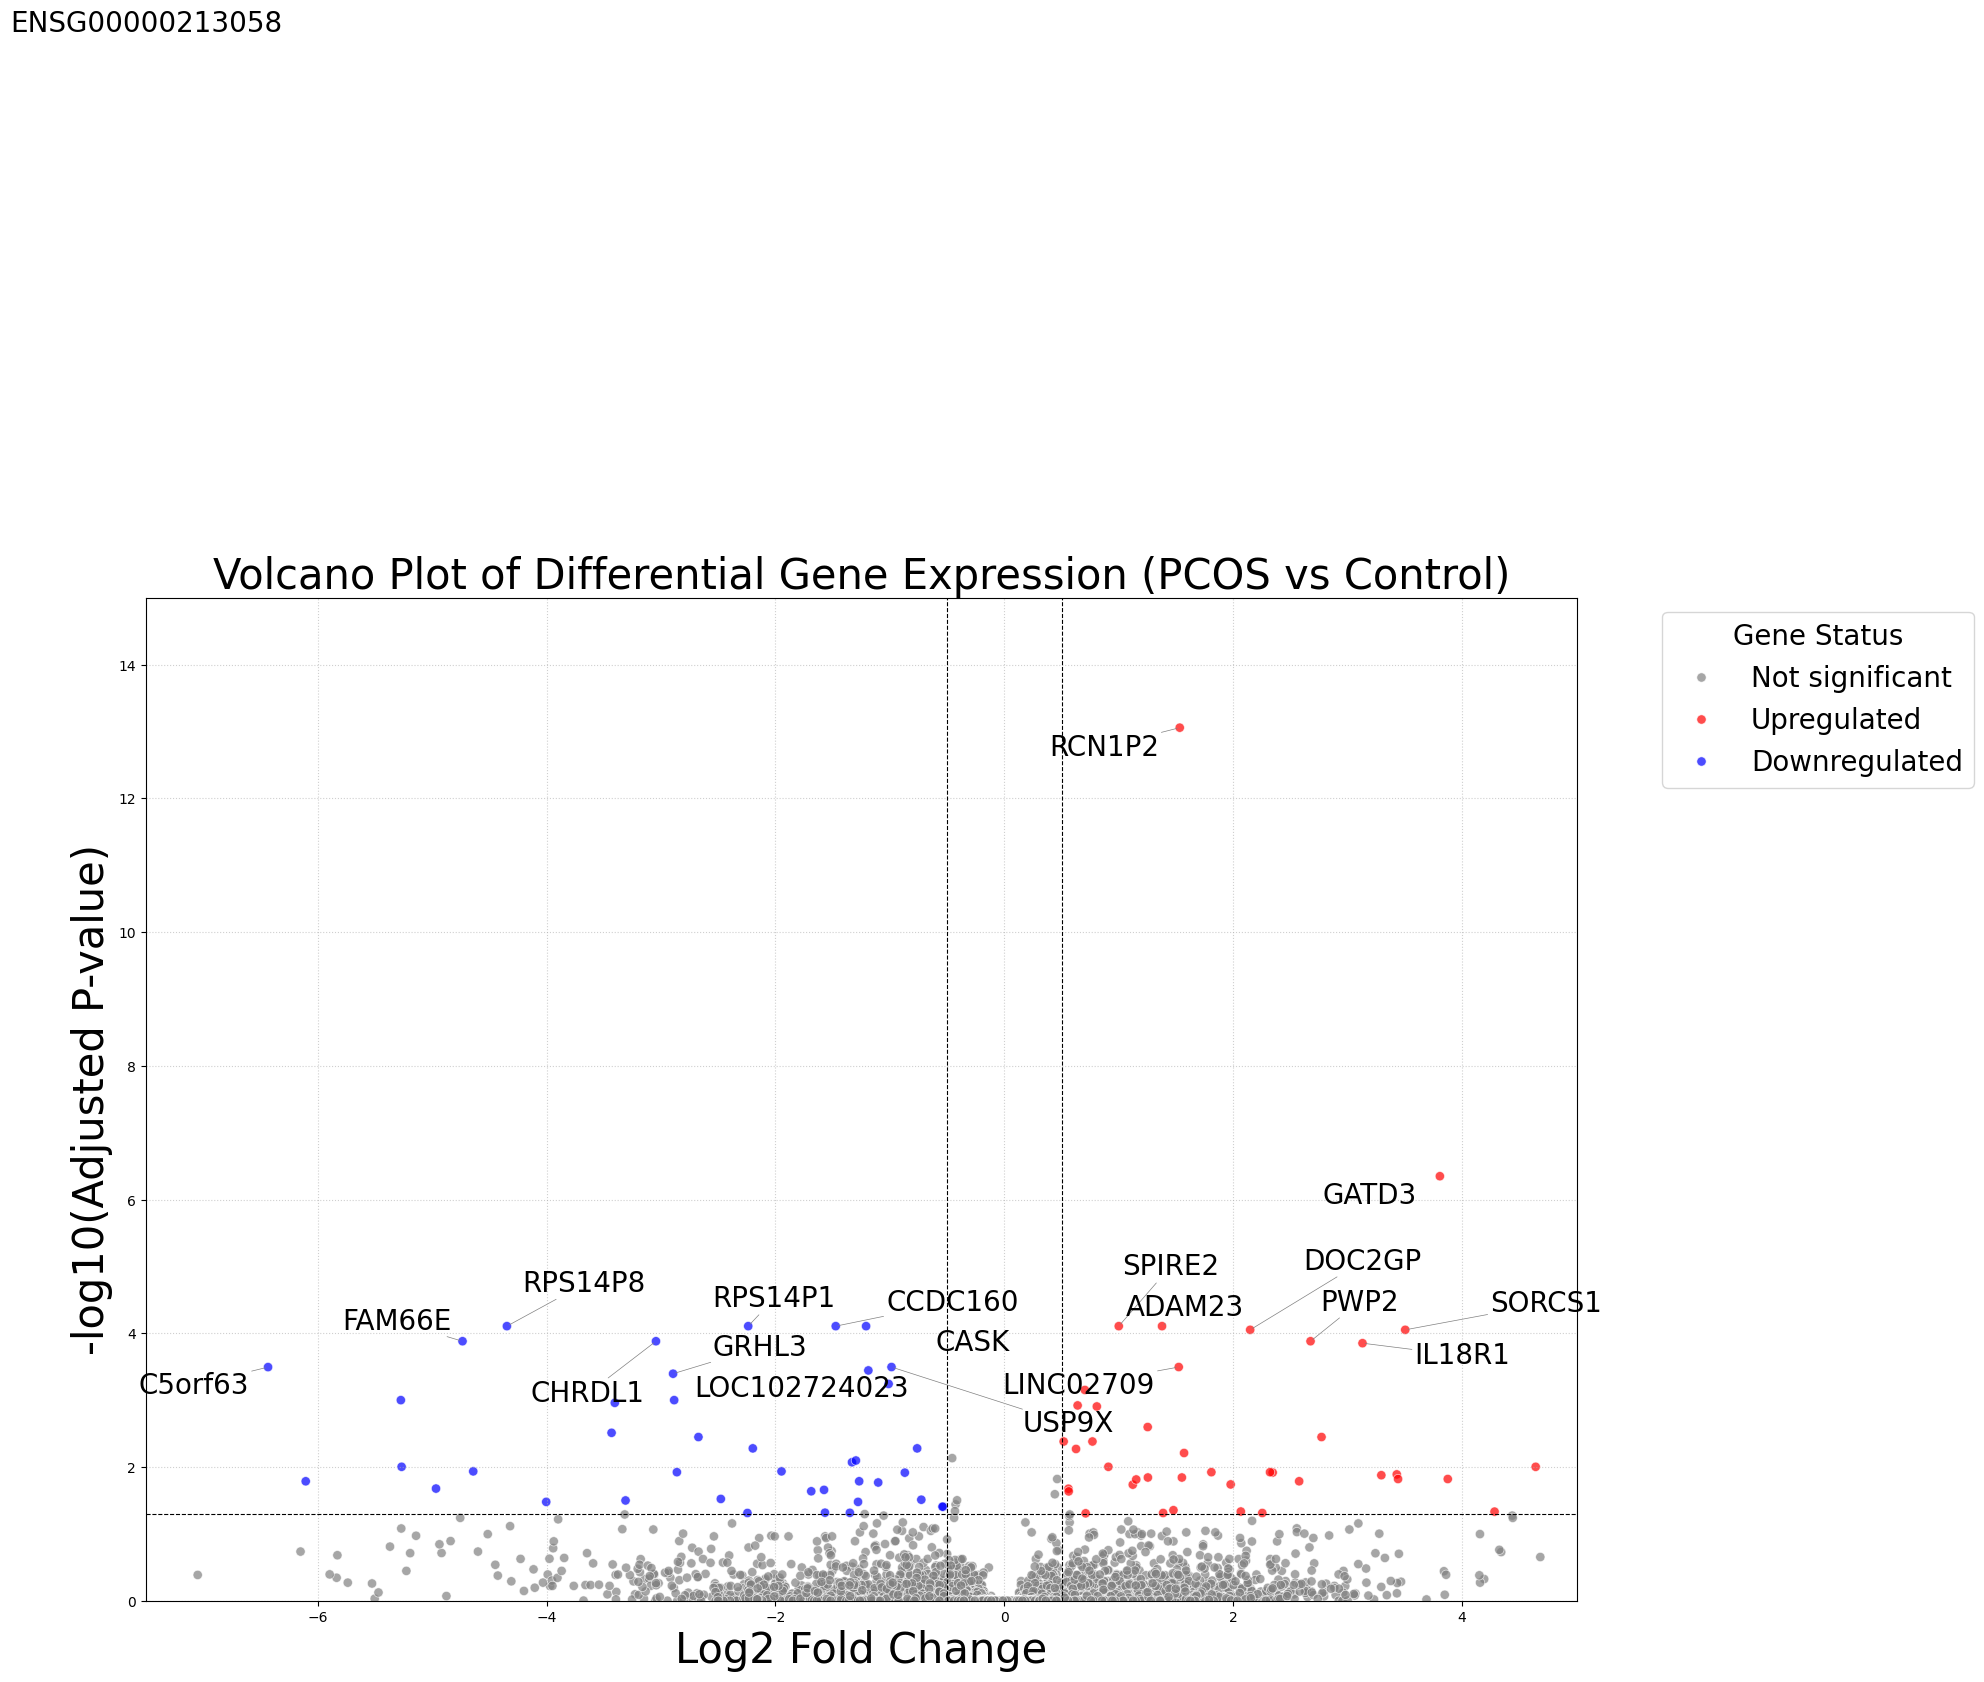

In [39]:
# Call the function to generate the labeled volcano plot with non-overlapping labels
plot_labeled_volcano(
    plot_df_labeled,
    genes_to_label,
    log2fc_threshold,
    p_adj_threshold,
    'Volcano Plot of Differential Gene Expression (PCOS vs Control)'
)

# Gene Regulatory Network

In [22]:
import pandas as pd
import numpy as np

# Extract normalized counts from your DESeq2 object
normalized_counts = dds.layers['normed_counts']  # or use dds.varm
expression_df = pd.DataFrame(normalized_counts,
                              index=dds.obs_names,
                              columns=dds.var_names).T

In [24]:
!pip install arboreto
from arboreto.algo import grnboost2
import pandas as pd
import numpy as np # Import numpy for numerical checks
from dask.distributed import Client, LocalCluster

# expression_df: genes as rows, samples as columns — transpose for arboreto
ex_matrix = expression_df.T  # samples x genes

diff_exp_gene_ids_versioned = differentially_expressed_genes.index.tolist()

genes_for_grn = [gene_id for gene_id in diff_exp_gene_ids_versioned if gene_id in ex_matrix.columns]

ex_matrix_filtered = ex_matrix[genes_for_grn]

# --- Data Cleaning for Stability ---
# 1. Handle potential NaN or Inf values by imputing with 0 or dropping. Given count data, NaNs might indicate missing values.
#    For GRN inference, 0 is often a safe imputation if there are no counts.
if ex_matrix_filtered.isnull().any().any():
    print("Warning: NaNs found in ex_matrix_filtered. Imputing with 0.")
    ex_matrix_filtered = ex_matrix_filtered.fillna(0)

# 2. Remove genes with zero variance across all samples, as these can cause numerical instability in some algorithms.
zero_variance_cols = ex_matrix_filtered.columns[ex_matrix_filtered.var(axis=0) == 0]
if not zero_variance_cols.empty:
    print(f"Warning: {len(zero_variance_cols)} genes with zero variance found. Removing them.")
    ex_matrix_filtered = ex_matrix_filtered.drop(columns=zero_variance_cols)

# Ensure all values are finite after any imputation
if not np.isfinite(ex_matrix_filtered).all().all():
    print("Warning: Non-finite values (Inf/-Inf) still present. Replacing with 0.")
    ex_matrix_filtered = ex_matrix_filtered.replace([np.inf, -np.inf], 0)

print(f"Performing GRN inference on {ex_matrix_filtered.shape[1]} differentially expressed genes with {ex_matrix_filtered.shape[0]} samples after cleaning.")

# Configure a local Dask cluster with a single worker for stability with small datasets
cluster = LocalCluster(n_workers=1, threads_per_worker=1, processes=False) # Use threads instead of processes for simplicity
client = Client(cluster)

# Run grnboost2 with the filtered and cleaned expression matrix, using the explicit Dask client
network = grnboost2(expression_data=ex_matrix_filtered, verbose=True, client_or_address=client)
network.to_csv('GRN_raw.csv', index=False)

# Close the Dask client after use
client.close()
cluster.close()

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36659 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: inproc://172.28.0.12/12404/10
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:36659/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.worker:      Start worker at: inproc://172.28.0.12/12404/13
INFO:distributed.worker:         Listening to:          inproc172.28.0.12
INFO:distributed.worker:          Worker name:                          0
INFO:distributed.worker:         dashboard at:          172.28.0.12:35451
INFO:distributed.worker:Waiting to connect to: inproc://172.28.0.12/12404/10
INFO:distributed.worker:-------------------------------------------------
INFO:distributed.worker:              Threads:                          1
INFO:distribu

Performing GRN inference on 86 differentially expressed genes with 8 samples after cleaning.
preparing dask client
parsing input
creating dask graph
not shutting down client, client was created externally
finished


TypeError: Must supply at least one delayed object

In [25]:
import pandas as pd

# Calculate the Pearson correlation matrix
correlation_matrix = ex_matrix_filtered.corr(method='pearson')

print("Pearson Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix.head())

Pearson Correlation Matrix (first 5 rows and columns):


0,ENSG00000215790.7,ENSG00000158055.16,ENSG00000178965.14,ENSG00000171488.15,ENSG00000233593.10,ENSG00000007341.19,ENSG00000277147.6,ENSG00000143603.19,ENSG00000213058.3,ENSG00000224114.1,...,ENSG00000086717.18,ENSG00000044446.12,ENSG00000124486.13,ENSG00000215301.11,ENSG00000147044.22,ENSG00000133142.17,ENSG00000157502.13,ENSG00000089682.16,ENSG00000101938.15,ENSG00000203952.9
0,,,,,,,,,,,,,,,,,,,,,
ENSG00000215790.7,1.000000,-0.590804,-0.645886,-0.643971,0.867146,0.880942,0.602287,-0.766569,-0.822386,-0.780436,...,-0.695950,-0.748158,-0.815704,-0.668545,-0.759953,-0.691874,0.548461,-0.747404,-0.641722,-0.833122
ENSG00000158055.16,-0.590804,1.000000,0.974428,0.800697,-0.671457,-0.748182,-0.811201,0.515104,0.849317,0.822851,...,0.891919,0.613363,0.839504,0.811446,0.874965,0.882468,-0.701266,0.576038,0.745924,0.647730
ENSG00000178965.14,-0.645886,0.974428,1.000000,0.788301,-0.726854,-0.791306,-0.861505,0.672976,0.913936,0.905551,...,0.894376,0.689970,0.838921,0.842967,0.892303,0.920800,-0.790460,0.653534,0.811735,0.699599
ENSG00000171488.15,-0.643971,0.800697,0.788301,1.000000,-0.697031,-0.815670,-0.816768,0.489782,0.723062,0.685681,...,0.961628,0.813557,0.833237,0.706337,0.736513,0.749882,-0.676457,0.748643,0.534576,0.832109
ENSG00000233593.10,0.867146,-0.671457,-0.726854,-0.697031,1.000000,0.842748,0.749181,-0.728306,-0.783486,-0.785927,...,-0.758390,-0.717505,-0.774996,-0.617069,-0.734621,-0.765236,0.681398,-0.596938,-0.593371,-0.703922


## Visualize Correlation Network

To visualize the correlation network, we'll follow these steps:

1.  **Define a correlation threshold:** We'll filter out correlations below a certain absolute value to focus on stronger relationships.
2.  **Create a graph:** We'll use the `networkx` library to build a graph where genes are nodes and edges represent correlations above our threshold.
3.  **Plot the graph:** We'll use `matplotlib` to draw the network, with different colors for positive and negative correlations.

The correlation matrix provides pairwise Pearson correlation coefficients between the expression levels of the differentially expressed genes. Values range from -1 to 1, where:

*   `1` indicates a perfect positive linear correlation.
*   `-1` indicates a perfect negative linear correlation.
*   `0` indicates no linear correlation.

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Define a correlation threshold
# Correlations with absolute values below this will be ignored.
correlation_threshold = 0.8 # You can adjust this value

# Create an empty graph
G = nx.Graph()

# Add nodes (genes) to the graph
genes = correlation_matrix.columns.tolist()
G.add_nodes_from(genes)

# Add edges based on the correlation matrix and threshold
# Iterate through the upper triangle of the correlation matrix to avoid duplicate edges
for i in range(len(genes)):
    for j in range(i + 1, len(genes)):
        gene1 = genes[i]
        gene2 = genes[j]
        correlation_value = correlation_matrix.loc[gene1, gene2]

        if abs(correlation_value) > correlation_threshold:
            # Add edge with correlation value as weight and color based on sign
            if correlation_value > 0:
                edge_color = 'skyblue'
            else:
                edge_color = 'salmon'

            G.add_edge(gene1, gene2, weight=correlation_value, color=edge_color)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges (threshold: {correlation_threshold})")


Graph created with 86 nodes and 1191 edges (threshold: 0.8)


In [27]:
import networkx as nx
import pandas as pd

# Calculate degree centrality for each node (gene)
degree_centrality = nx.degree_centrality(G)

# Convert to a pandas Series for easier sorting and analysis
degree_df = pd.Series(degree_centrality).sort_values(ascending=False)

print("Top 10 Hub Genes by Degree Centrality:")
# Display the top 10 genes with the highest degree centrality
# We'll map the Ensembl IDs to GeneSymbols for better readability if available
hub_genes_with_symbols = []
for gene_id, centrality_score in degree_df.head(10).items():
    unversioned_id = gene_id.split('.')[0]
    gene_symbol = None
    if gene_id in differentially_expressed_genes.index and pd.notna(differentially_expressed_genes.loc[gene_id, 'GeneSymbol']):
        gene_symbol = differentially_expressed_genes.loc[gene_id, 'GeneSymbol']
    else:
        gene_symbol = unversioned_id # Fallback to unversioned Ensembl ID
    hub_genes_with_symbols.append({'GeneID': gene_id, 'GeneSymbol': gene_symbol, 'Degree Centrality': centrality_score})

display(pd.DataFrame(hub_genes_with_symbols))


Top 10 Hub Genes by Degree Centrality:


,GeneID,GeneSymbol,Degree Centrality
0,ENSG00000239528.1,RPS14P8,0.670588
1,ENSG00000231793.5,DOC2GP,0.623529
2,ENSG00000213058.3,ENSG00000213058,0.611765
3,ENSG00000224114.1,RPS14P1,0.600000
4,ENSG00000204991.11,SPIRE2,0.576471
5,ENSG00000137207.12,YIPF3,0.576471
6,ENSG00000203952.9,CCDC160,0.564706
7,ENSG00000214455.4,RCN1P2,0.564706
8,ENSG00000280071.4,LOC102724023,0.564706
9,ENSG00000279453.1,ENSG00000279453,0.552941


## Understanding Degree Centrality

**Degree Centrality** is a fundamental metric in network analysis that measures the number of direct connections a node (in this case, a gene) has within a network. In simpler terms, it quantifies how many other genes a particular gene is correlated with above a defined threshold.

### How it's Calculated:

For a given gene, its degree centrality is simply the count of edges (significant correlations) connected to it. In the context of our correlation network, if a gene 'X' has a high degree centrality, it means gene 'X' shows a strong correlation (either positive or negative) with many other genes in the network.

### What it Means:

*   **High Degree Centrality (Hub Genes):** Genes with high degree centrality are often considered **'hub genes'**. They are highly connected and play crucial roles in information flow or regulatory processes within the network. Perturbations to these genes might have widespread effects on the expression of many other genes.
*   **Low Degree Centrality:** Genes with low degree centrality have fewer direct connections, suggesting they might be more peripheral to the core regulatory mechanisms or involved in more specialized pathways.

In our analysis, a higher degree centrality for a gene indicates that it is significantly correlated with a larger number of other differentially expressed genes in the PCOS vs. Control comparison, making it a potentially important player in the disease's molecular landscape.

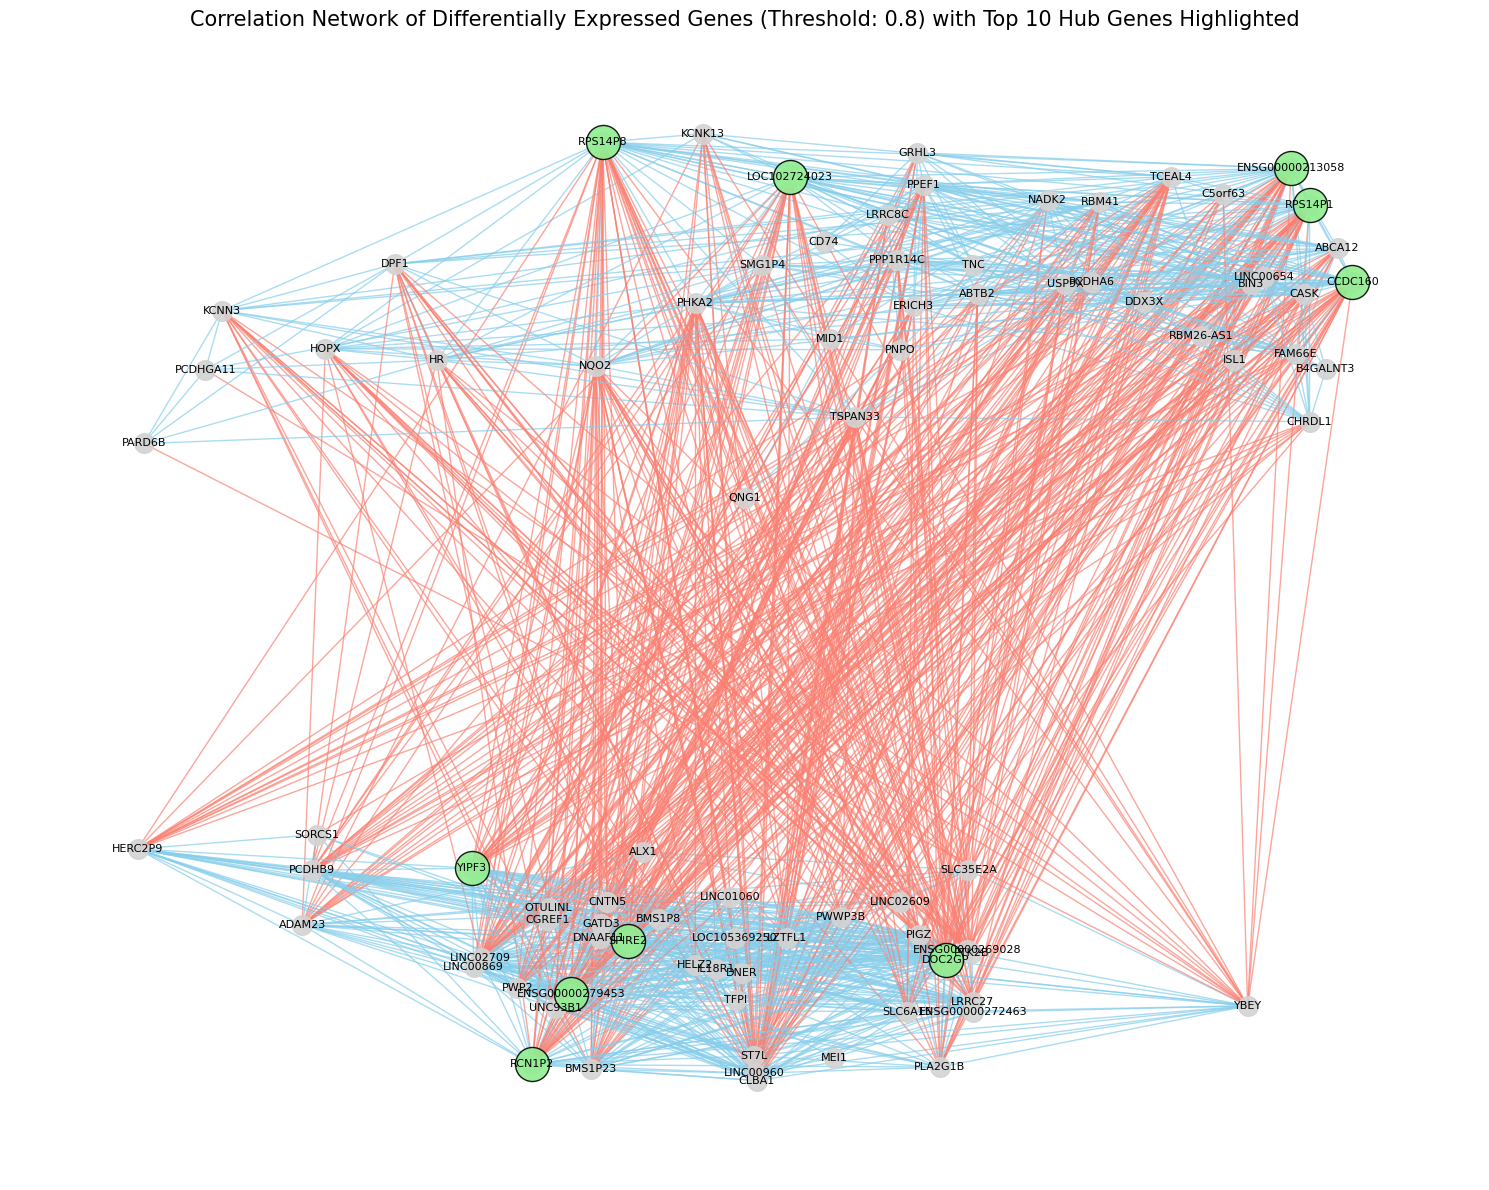

In [28]:
# Prepare for plotting

# Get node positions for visualization using a spring layout
pos = nx.spring_layout(G, k=0.3, iterations=50) # k regulates the distance between nodes

# Get edge colors for plotting
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]

# Get the gene IDs of the top 10 hub genes
top_10_hub_gene_ids = degree_df.head(10).index.tolist()

# Set figure size
plt.figure(figsize=(15, 12))

# Draw all nodes initially with a default style
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='lightgray', alpha=0.9)

# Draw hub genes with a different color and larger size to highlight them
nx.draw_networkx_nodes(G, pos, nodelist=top_10_hub_gene_ids, node_size=600, node_color='lightgreen', alpha=0.9, linewidths=1.0, edgecolors='black')

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=1, alpha=0.7)

# Draw labels for the nodes
node_labels = {}
for gene_id in G.nodes():
    unversioned_id = gene_id.split('.')[0]
    # Check if the gene is in differentially_expressed_genes and has a symbol
    if gene_id in differentially_expressed_genes.index and pd.notna(differentially_expressed_genes.loc[gene_id, 'GeneSymbol']):
        node_labels[gene_id] = differentially_expressed_genes.loc[gene_id, 'GeneSymbol']
    else:
        node_labels[gene_id] = unversioned_id # Fallback to unversioned Ensembl ID

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='black')

plt.title(f'Correlation Network of Differentially Expressed Genes (Threshold: {correlation_threshold}) with Top 10 Hub Genes Highlighted', size=15)
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

## Degree Centrality Distribution

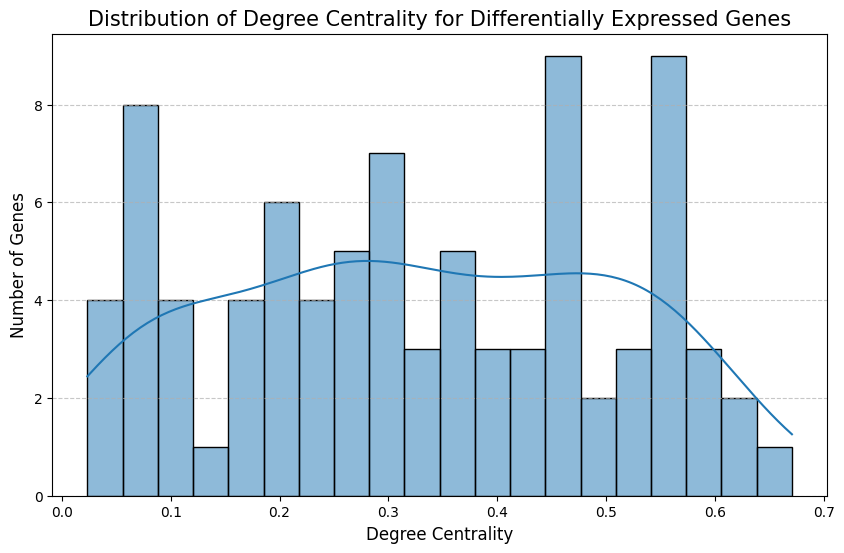

This histogram visualizes the distribution of degree centrality values across all differentially expressed genes.
A higher concentration of genes at certain centrality values indicates common connectivity patterns within the network.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert degree_df Series to DataFrame for easier plotting
degree_distribution_df = degree_df.reset_index()
degree_distribution_df.columns = ['GeneID', 'DegreeCentrality']

plt.figure(figsize=(10, 6))
sns.histplot(degree_distribution_df['DegreeCentrality'], kde=True, bins=20)
plt.title('Distribution of Degree Centrality for Differentially Expressed Genes', fontsize=15)
plt.xlabel('Degree Centrality', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("This histogram visualizes the distribution of degree centrality values across all differentially expressed genes.")
print("A higher concentration of genes at certain centrality values indicates common connectivity patterns within the network.")

## Degree Centrality for Each Gene

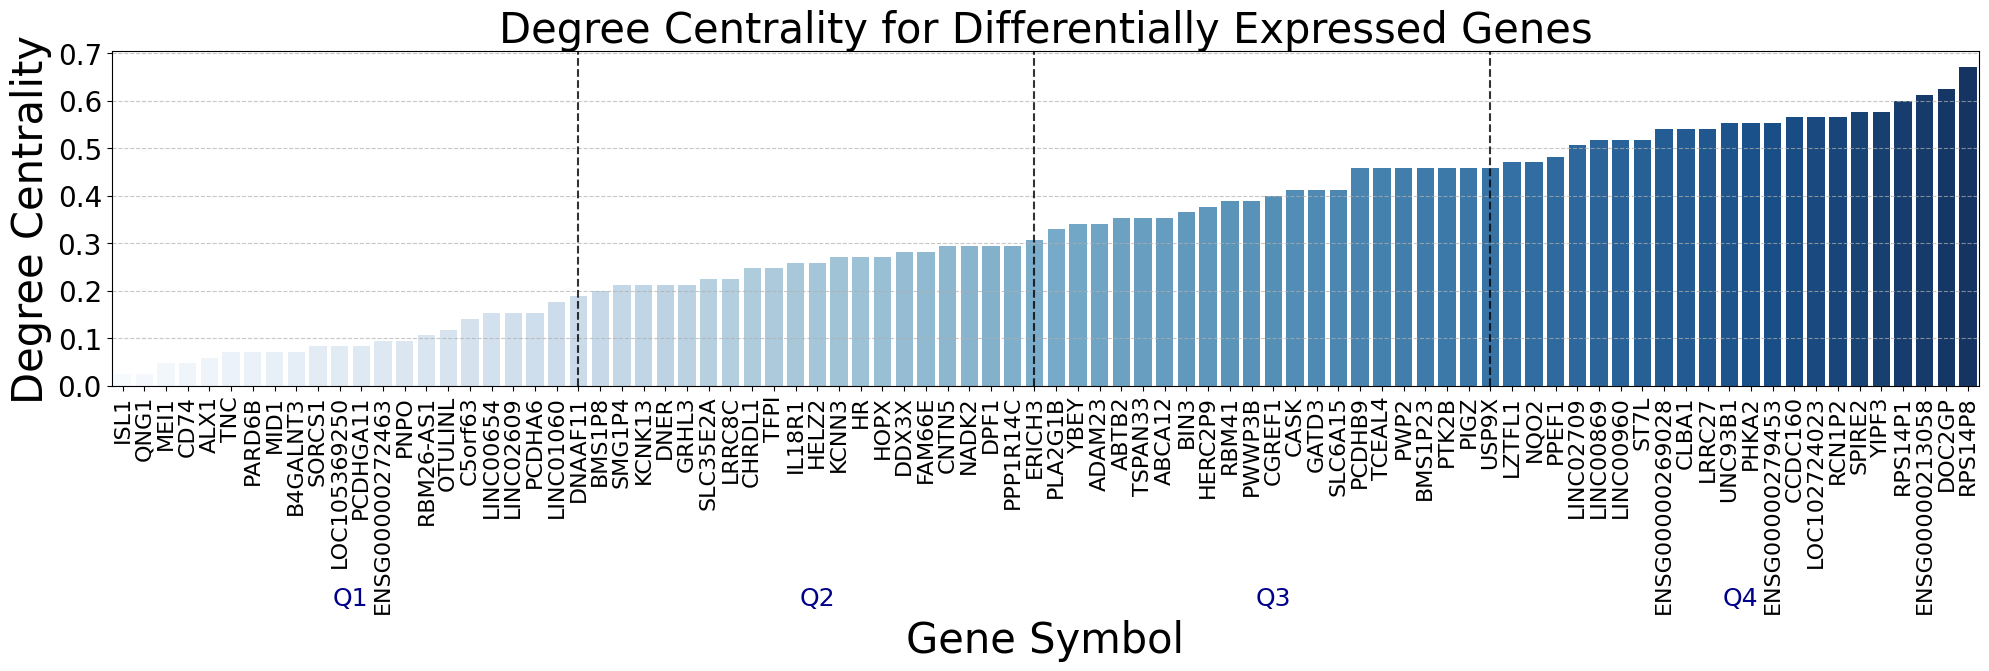

This plot shows the degree centrality value for each differentially expressed gene, sorted from lowest to highest. Vertical lines now delineate the quartiles, and quartile labels are added at the bottom.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use degree_info_df which already has the 'Quartile' column and is sorted.
# We need to sort it ascending for the plot to show lowest centrality first.
plot_data = degree_info_df.sort_values(by='DegreeCentrality', ascending=True).copy()

# Ensure 'DisplayGene' column is present for x-axis labels
plot_data['DisplayGene'] = plot_data['GeneSymbol'].fillna(plot_data['EnsemblID'].apply(lambda x: x.split('.')[0]))

plt.figure(figsize=(20, 8)) # Increase figure size for better readability of gene labels
sns.barplot(x='DisplayGene', y='DegreeCentrality', data=plot_data, palette='Blues')
plt.title('Degree Centrality for Differentially Expressed Genes', fontsize=30)
plt.xlabel('Gene Symbol', fontsize=30) # Changed label to 'Gene Symbol'
plt.ylabel('Degree Centrality', fontsize=30)
plt.xticks(rotation=90, fontsize=16) # Rotate x-axis labels for better visibility and reduced font size for readability
plt.yticks(fontsize = 20)

# Add vertical lines to delineate quartiles
# We need to find the x-axis positions where each quartile ends.

# Get the unique quartile values in ascending order
unique_quartiles = sorted(plot_data['Quartile'].unique())

# Initialize a list to store x-positions for vertical lines
vertical_line_positions = []
current_position = -0.5 # Start before the first bar

for q_label in unique_quartiles:
    # Get the number of genes in the current quartile
    num_genes_in_quartile = plot_data[plot_data['Quartile'] == q_label].shape[0]
    # The vertical line should be placed after the last gene of the current quartile
    current_position += num_genes_in_quartile
    if q_label < max(unique_quartiles): # Don't draw a line after the last quartile
        vertical_line_positions.append(current_position - 0.5) # Adjust for bar width (0.5 for half bar width)

# Draw vertical lines
for x_pos in vertical_line_positions:
    plt.axvline(x=x_pos, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

# Add labels for the quartiles below the x-axis
# Find the center position for each quartile
quartile_centers = []
start_index = 0
for q_label in unique_quartiles:
    num_genes = plot_data[plot_data['Quartile'] == q_label].shape[0]
    center = start_index + (num_genes / 2) - 0.5 # Adjust for x-axis indexing to center text within quartile
    quartile_centers.append(center)
    start_index += num_genes

for i, center in enumerate(quartile_centers):
    plt.text(center, plt.ylim()[0] - 0.6 * (plt.ylim()[1] - plt.ylim()[0]), # Position slightly below x-axis
             f'Q{unique_quartiles[i]}', # Label with Quartile number
             ha='center', va='top', fontsize=18, color='darkblue',
             transform=plt.gca().transData)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("This plot shows the degree centrality value for each differentially expressed gene, sorted from lowest to highest. Vertical lines now delineate the quartiles, and quartile labels are added at the bottom.")

## Gene Set Enrichment Analysis (GSEA) by Degree Centrality Quartiles

To understand the biological functions associated with genes having different levels of connectivity, we will perform Gene Set Enrichment Analysis (GSEA). We'll divide the genes into four quartiles based on their degree centrality and then run GSEA on each set of genes.

In [31]:
print("Installing gseapy library...")
!pip install gseapy -qq
print("gseapy library installed.")

Installing gseapy library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 19.1 MB/s eta 0:00:00
gseapy library installed.


In [60]:
import gseapy
import pandas as pd
import numpy as np

# 1. Prepare a DataFrame with GeneID, GeneSymbol, and DegreeCentrality
# We start with degree_df (Series of EnsemblID -> DegreeCentrality)
degree_info_df = degree_df.reset_index()
degree_info_df.columns = ['EnsemblID', 'DegreeCentrality']

# Merge with differentially_expressed_genes to get GeneSymbols
# Ensure 'GeneSymbol' is extracted correctly, handling potential NaNs
degree_info_df = degree_info_df.merge(
    differentially_expressed_genes[['GeneSymbol']],
    left_on='EnsemblID',
    right_index=True,
    how='left'
)

# Fallback to EnsemblID if GeneSymbol is NaN
degree_info_df['GeneSymbol'] = degree_info_df['GeneSymbol'].fillna(degree_info_df['EnsemblID'].apply(lambda x: x.split('.')[0]))

# Sort by DegreeCentrality to facilitate quartile division
degree_info_df = degree_info_df.sort_values(by='DegreeCentrality', ascending=False).reset_index(drop=True)

# 2. Divide genes into quartiles based on Degree Centrality
degree_info_df['Quartile'] = pd.qcut(
    degree_info_df['DegreeCentrality'],
    q=4,
    labels=[1, 2, 3, 4], # Label quartiles from lowest to highest centrality
    duplicates='drop' # Handle cases where there might be duplicate centrality values
)

# If duplicates='drop' results in fewer than 4 unique labels, adjust labels manually if needed
# For simplicity, we'll proceed assuming 4 distinct labels are formed.

print("Genes assigned to quartiles based on Degree Centrality. First 10 rows:")
display(degree_info_df.head(10))
print("\nNumber of genes per quartile:")
print(degree_info_df['Quartile'].value_counts().sort_index())

# Create gene lists for each quartile using gene symbols
gene_lists_by_quartile = {}
for q in sorted(degree_info_df['Quartile'].unique()):
    genes_in_quartile = degree_info_df[degree_info_df['Quartile'] == q]['GeneSymbol'].tolist()
    # Filter out None values in case some symbols couldn't be resolved
    genes_in_quartile = [gene for gene in genes_in_quartile if gene is not None and gene != '']
    gene_lists_by_quartile[q] = genes_in_quartile

print("\nGene lists prepared for each quartile.")

Genes assigned to quartiles based on Degree Centrality. First 10 rows:


,EnsemblID,DegreeCentrality,GeneSymbol,Quartile
0,ENSG00000239528.1,0.670588,RPS14P8,4
1,ENSG00000231793.5,0.623529,DOC2GP,4
2,ENSG00000213058.3,0.611765,ENSG00000213058,4
3,ENSG00000224114.1,0.600000,RPS14P1,4
4,ENSG00000204991.11,0.576471,SPIRE2,4
5,ENSG00000137207.12,0.576471,YIPF3,4
6,ENSG00000203952.9,0.564706,CCDC160,4
7,ENSG00000214455.4,0.564706,RCN1P2,4
8,ENSG00000280071.4,0.564706,LOC102724023,4
9,ENSG00000279453.1,0.552941,ENSG00000279453,4



Number of genes per quartile:
Quartile
1    22
2    21
3    21
4    22
Name: count, dtype: int64

Gene lists prepared for each quartile.


### GSEA for Quartile 1 (Lowest Degree Centrality)

This quartile contains genes with the lowest connectivity in the network.

In [61]:
# Perform GSEA for Quartile 1
# Using 'GO_Biological_Process_2021' as an example gene set database
# You can choose other gene sets from gseapy.get_library_name()

q1_genes = gene_lists_by_quartile.get(1, [])

if q1_genes:
    print(f"Running GSEA for {len(q1_genes)} genes in Quartile 1...")
    enrichment_results_q1 = gseapy.enrichr(
        gene_list=q1_genes,
        gene_sets='GO_Biological_Process_2021', # Example database
        organism='homo sapiens', # or 'Mouse', 'Yeast', etc.
        outdir=None, # Set to a directory if you want to save results
        verbose=True,
        cutoff=0.05 # p-value cutoff
    )
    print("GSEA Results for Quartile 1 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q1.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 1 for GSEA.")

Running GSEA for 22 genes in Quartile 1...


2026-04-29 21:29:32,198 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-04-29 21:29:32,378 [INFO] Done.


GSEA Results for Quartile 1 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,positive regulation of interleukin-6 productio...,2/76,0.003134,0.069848,0,0,26.897297,155.078347,CD74;ISL1
1,GO_Biological_Process_2021,cell morphogenesis involved in neuron differen...,2/76,0.003134,0.069848,0,0,26.897297,155.078347,PARD6B;ISL1
2,GO_Biological_Process_2021,axon development (GO:0061564),2/79,0.003381,0.069848,0,0,25.845455,147.051121,PARD6B;ISL1
3,GO_Biological_Process_2021,sinoatrial node cell differentiation (GO:0060921),1/5,0.005488,0.069848,0,0,237.785714,1237.703279,ISL1
4,GO_Biological_Process_2021,regulation of granulocyte colony-stimulating f...,1/5,0.005488,0.069848,0,0,237.785714,1237.703279,ISL1
5,GO_Biological_Process_2021,positive regulation of prostaglandin biosynthe...,1/5,0.005488,0.069848,0,0,237.785714,1237.703279,CD74
6,GO_Biological_Process_2021,pyridine-containing compound metabolic process...,1/5,0.005488,0.069848,0,0,237.785714,1237.703279,PNPO
7,GO_Biological_Process_2021,regulation of interleukin-1 alpha production (...,1/5,0.005488,0.069848,0,0,237.785714,1237.703279,ISL1
8,GO_Biological_Process_2021,heart field specification (GO:0003128),1/5,0.005488,0.069848,0,0,237.785714,1237.703279,ISL1
9,GO_Biological_Process_2021,cardiac cell fate commitment (GO:0060911),1/5,0.005488,0.069848,0,0,237.785714,1237.703279,ISL1


### GSEA for Quartile 2

In [62]:
# Perform GSEA for Quartile 2
q2_genes = gene_lists_by_quartile.get(2, [])

if q2_genes:
    print(f"Running GSEA for {len(q2_genes)} genes in Quartile 2...")
    enrichment_results_q2 = gseapy.enrichr(
        gene_list=q2_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 2 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q2.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 2 for GSEA.")

Running GSEA for 21 genes in Quartile 2...


2026-04-29 21:29:50,035 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-04-29 21:29:50,217 [INFO] Done.


GSEA Results for Quartile 2 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of T-helper 1 cell cytokine product...,1/5,0.005239,0.080208,0,0,249.687500,1311.244059,IL18R1
1,GO_Biological_Process_2021,mature ribosome assembly (GO:0042256),1/5,0.005239,0.080208,0,0,249.687500,1311.244059,DDX3X
2,GO_Biological_Process_2021,cyclic-GMP-AMP transmembrane import across pla...,1/5,0.005239,0.080208,0,0,249.687500,1311.244059,LRRC8C
3,GO_Biological_Process_2021,positive regulation of T-helper 1 cell cytokin...,1/5,0.005239,0.080208,0,0,249.687500,1311.244059,IL18R1
4,GO_Biological_Process_2021,positive regulation of translation in response...,1/5,0.005239,0.080208,0,0,249.687500,1311.244059,DDX3X
5,GO_Biological_Process_2021,His-Purkinje system development (GO:0003164),1/5,0.005239,0.080208,0,0,249.687500,1311.244059,HOPX
6,GO_Biological_Process_2021,positive regulation of toll-like receptor 7 si...,1/6,0.006284,0.080208,0,0,199.740000,1012.625496,DDX3X
7,GO_Biological_Process_2021,guanine nucleotide transmembrane transport (GO...,1/6,0.006284,0.080208,0,0,199.740000,1012.625496,LRRC8C
8,GO_Biological_Process_2021,potassium ion transport (GO:0006813),2/122,0.007184,0.080208,0,0,17.420175,85.983506,KCNK13;KCNN3
9,GO_Biological_Process_2021,cellular response to interleukin-18 (GO:0071351),1/7,0.007328,0.080208,0,0,166.441667,818.238307,IL18R1


### GSEA for Quartile 3

In [63]:
# Perform GSEA for Quartile 3
q3_genes = gene_lists_by_quartile.get(3, [])

if q3_genes:
    print(f"Running GSEA for {len(q3_genes)} genes in Quartile 3...")
    enrichment_results_q3 = gseapy.enrichr(
        gene_list=q3_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 3 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q3.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 3 for GSEA.")

Running GSEA for 21 genes in Quartile 3...


2026-04-29 21:29:58,887 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-04-29 21:29:59,132 [INFO] Done.


GSEA Results for Quartile 3 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,supramolecular fiber organization (GO:0097435),4/351,0.000441,0.09876,0,0,13.312087,102.866146,BIN3;USP9X;PLA2G1B;TSPAN33
1,GO_Biological_Process_2021,amyloid fibril formation (GO:1990000),2/63,0.001973,0.09876,0,0,34.371009,214.068429,USP9X;TSPAN33
2,GO_Biological_Process_2021,regulation of cell-matrix adhesion (GO:0001952),2/65,0.002099,0.09876,0,0,33.276525,205.197377,CASK;PTK2B
3,GO_Biological_Process_2021,neurotransmitter transport (GO:0006836),2/73,0.002638,0.09876,0,0,29.515196,175.250272,SLC6A15;CASK
4,GO_Biological_Process_2021,glycerophospholipid metabolic process (GO:0006...,2/80,0.003158,0.09876,0,0,26.856950,154.634257,PLA2G1B;PIGZ
5,GO_Biological_Process_2021,positive regulation of phospholipase A2 activi...,1/5,0.005239,0.09876,0,0,249.687500,1311.244059,PLA2G1B
6,GO_Biological_Process_2021,regulation of inositol trisphosphate biosynthe...,1/5,0.005239,0.09876,0,0,249.687500,1311.244059,PTK2B
7,GO_Biological_Process_2021,positive regulation of DNA demethylation (GO:1...,1/5,0.005239,0.09876,0,0,249.687500,1311.244059,USP9X
8,GO_Biological_Process_2021,endothelin receptor signaling pathway (GO:0086...,1/5,0.005239,0.09876,0,0,249.687500,1311.244059,PTK2B
41,GO_Biological_Process_2021,regulation of establishment of cell polarity (...,1/16,0.016674,0.09876,0,0,66.546667,272.434060,PTK2B


### GSEA for Quartile 4 (Highest Degree Centrality)

This quartile contains genes with the highest connectivity (hub genes) in the network.

In [99]:
# Perform GSEA for Quartile 4
q4_genes = gene_lists_by_quartile.get(4, [])

if q4_genes:
    print(f"Running GSEA for {len(q4_genes)} genes in Quartile 4...")
    enrichment_results_q4 = gseapy.enrichr(
        gene_list=q4_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 4 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q4.results.sort_values(by='Adjusted P-value').head(22))
else:
    print("No genes found in Quartile 4 for GSEA.")

Running GSEA for 22 genes in Quartile 4...


2026-04-29 22:44:08,778 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-04-29 22:44:08,957 [INFO] Done.


GSEA Results for Quartile 4 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,quinone catabolic process (GO:1901662),1/5,0.005488,0.080325,0,0,237.785714,1237.703279,NQO2
1,GO_Biological_Process_2021,regulation of protein localization to cilium (...,1/6,0.006583,0.080325,0,0,190.219048,955.531692,LZTFL1
2,GO_Biological_Process_2021,cleavage furrow formation (GO:0036089),1/7,0.007676,0.080325,0,0,158.507937,771.885508,SPIRE2
3,GO_Biological_Process_2021,parallel actin filament bundle assembly (GO:00...,1/7,0.007676,0.080325,0,0,158.507937,771.885508,SPIRE2
4,GO_Biological_Process_2021,actin filament network formation (GO:0051639),1/11,0.012037,0.080325,0,0,95.085714,420.260566,SPIRE2
5,GO_Biological_Process_2021,toll-like receptor 3 signaling pathway (GO:003...,1/12,0.013124,0.080325,0,0,86.437229,374.560204,UNC93B1
6,GO_Biological_Process_2021,toll-like receptor 9 signaling pathway (GO:003...,1/13,0.014210,0.080325,0,0,79.230159,337.029380,UNC93B1
7,GO_Biological_Process_2021,glycogen catabolic process (GO:0005980),1/15,0.016379,0.080325,0,0,67.904762,279.207319,PHKA2
8,GO_Biological_Process_2021,glucan catabolic process (GO:0009251),1/15,0.016379,0.080325,0,0,67.904762,279.207319,PHKA2
9,GO_Biological_Process_2021,cellular polysaccharide catabolic process (GO:...,1/16,0.017462,0.080325,0,0,63.374603,256.523542,PHKA2


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming enrichment_results_q1, enrichment_results_q2, enrichment_results_q3, enrichment_results_q4 are available
# and are gseapy.enrichr.EnrichrResult objects.

# Define the number of top terms to consider from each quartile
num_top_terms = 20 # Adjust as needed

all_quartile_results = {
    'Quartile_1': enrichment_results_q1,
    'Quartile_2': enrichment_results_q2,
    'Quartile_3': enrichment_results_q3,
    'Quartile_4': enrichment_results_q4,
}

# Collect top terms and their Combined Scores from each quartile
combined_scores_data = []
all_terms = set()

for q_name, enrichr_result in all_quartile_results.items():
    if enrichr_result and not enrichr_result.results.empty:
        # Sort by 'Adjusted P-value' and then take 'num_top_terms'
        top_terms_df = enrichr_result.results.sort_values(by='Adjusted P-value').head(num_top_terms)
        for index, row in top_terms_df.iterrows():
            term = row['Term']
            combined_score = row['Combined Score']
            combined_scores_data.append({'Term': term, 'Quartile': q_name, 'Combined_Score': combined_score})
            all_terms.add(term)

# Create a DataFrame from the collected data
heatmap_df = pd.DataFrame(combined_scores_data)

# Pivot the DataFrame to get Terms as index and Quartiles as columns, with Combined_Score as values
# We take the maximum score if a term appears multiple times in a quartile (e.g., if num_top_terms allows it)
heatmap_pivot = heatmap_df.pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

# Filter for terms that appear in at least two quartiles to focus on shared pathways
# Or, uncomment the line below to show all terms collected across all top lists
# heatmap_pivot = heatmap_pivot[heatmap_pivot.notna().sum(axis=1) >= 1]

# Sort by overall enrichment or by first quartile for better visualization
# heatmap_pivot = heatmap_pivot.sort_values(by=list(heatmap_pivot.columns), ascending=False)

print(f"Heatmap data prepared for {len(heatmap_pivot)} terms. Top 5 rows:")
display(heatmap_pivot.head())

Heatmap data prepared for 80 terms. Top 5 rows:


Quartile,Quartile_1,Quartile_2,Quartile_3,Quartile_4
Term,,,,
His-Purkinje system development (GO:0003164),NaN,1311.244059,NaN,NaN
RNA secondary structure unwinding (GO:0010501),NaN,682.334006,NaN,NaN
actin filament network formation (GO:0051639),NaN,NaN,NaN,420.260566
actin filament polymerization (GO:0030041),NaN,NaN,NaN,117.387149
actin nucleation (GO:0045010),NaN,NaN,NaN,179.546868


In [86]:
import re

# Function to remove GO ID from a term string
def remove_go_id(term):
    # Regular expression to find and remove (GO:XXXXXXXX) pattern
    return re.sub(r' \(GO:\d+\)', '', term).strip()

# Apply the function to the 'Term' column of heatmap_df
heatmap_df['Term'] = heatmap_df['Term'].apply(remove_go_id)

# Re-pivot the DataFrame with the cleaned terms
heatmap_pivot = heatmap_df.pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

print("GO IDs removed from terms in heatmap_df. Updated heatmap_pivot:")
display(heatmap_pivot.head())

GO IDs removed from terms in heatmap_df. Updated heatmap_pivot:


Quartile,Quartile_1,Quartile_2,Quartile_3,Quartile_4
Term,,,,
His-Purkinje system development,NaN,1311.244059,NaN,NaN
RNA secondary structure unwinding,NaN,682.334006,NaN,NaN
actin filament network formation,NaN,NaN,NaN,420.260566
actin filament polymerization,NaN,NaN,NaN,117.387149
actin nucleation,NaN,NaN,NaN,179.546868


With the GO IDs removed from the terms, let's re-plot the heatmaps to reflect this change.

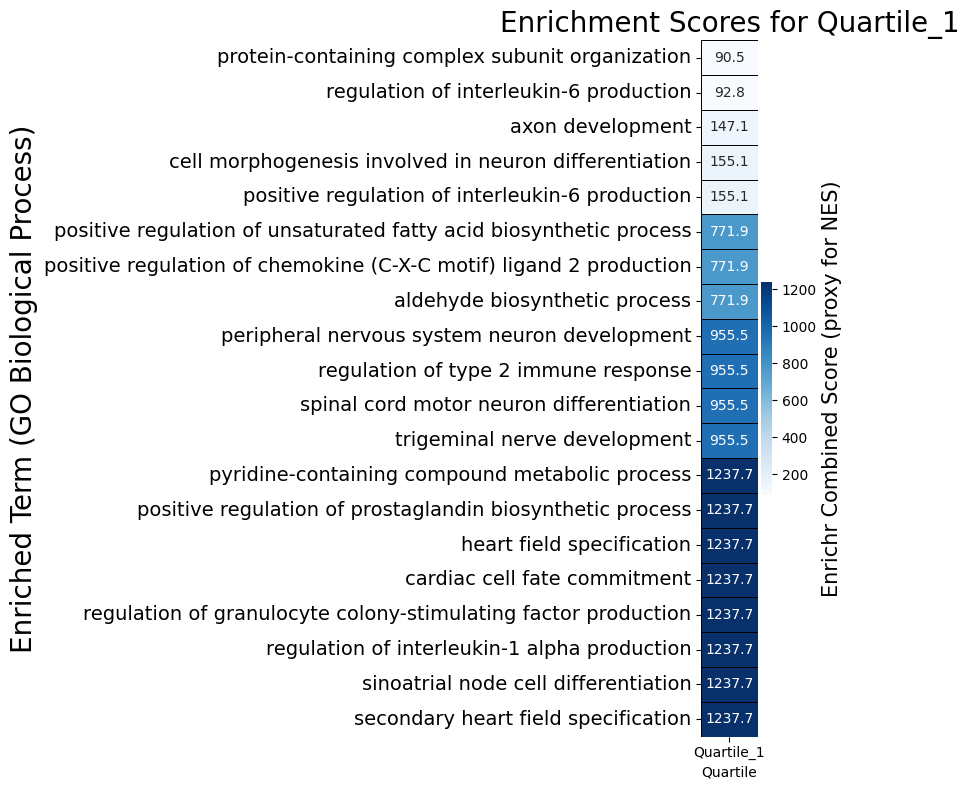

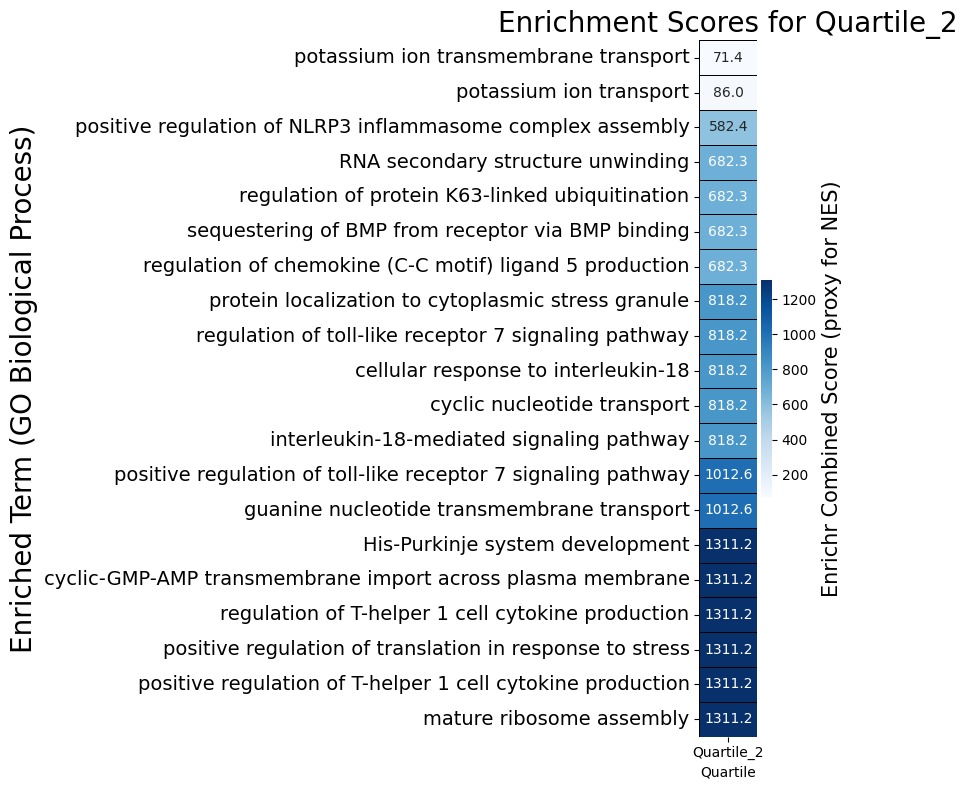

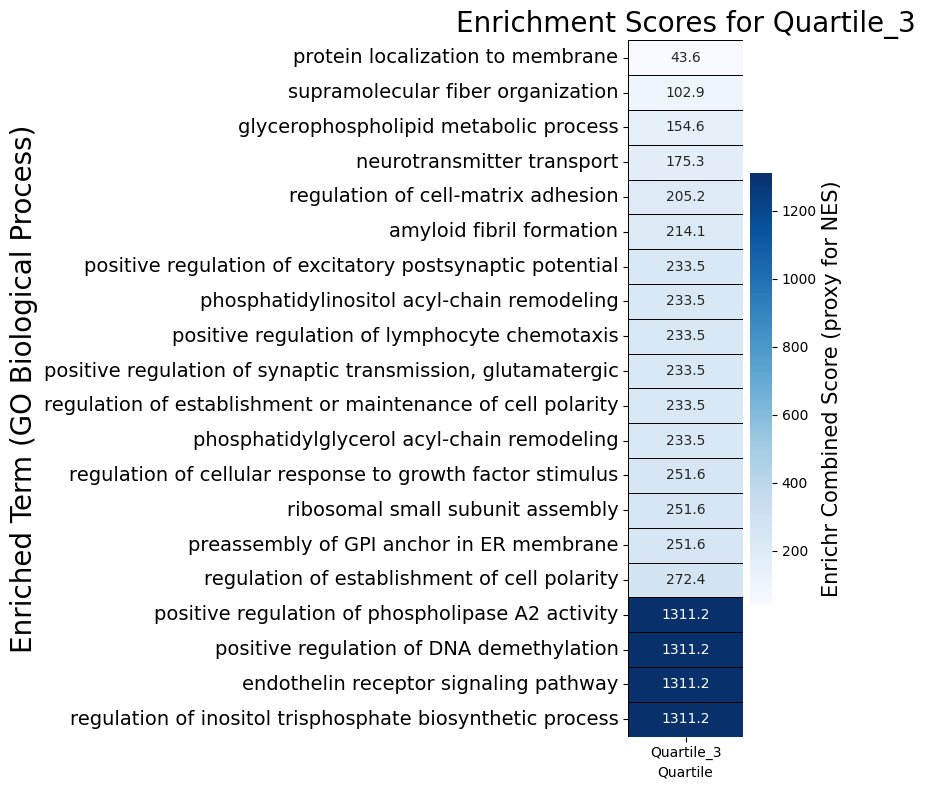

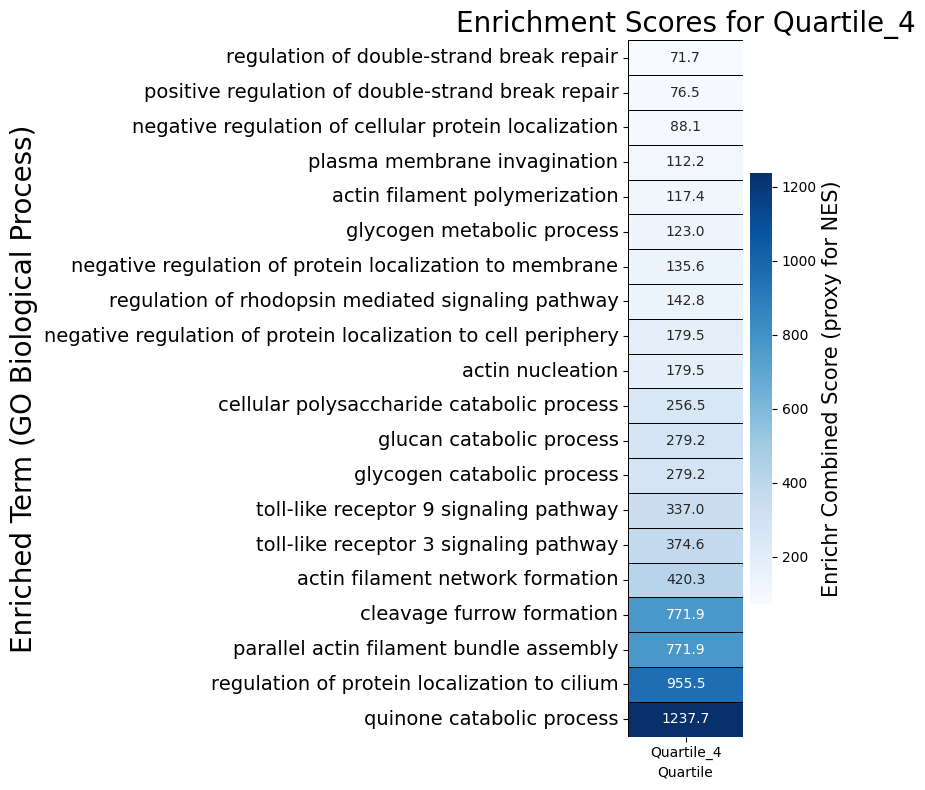

These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each quartile and create a separate heatmap
for q_name in ['Quartile_1', 'Quartile_2', 'Quartile_3', 'Quartile_4']: # Corrected names to use underscores
    # Extract data for the current quartile
    # Filter the heatmap_df to include only terms present in the current quartile's top terms
    current_quartile_data = heatmap_df[heatmap_df['Quartile'] == q_name].pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

    if not current_quartile_data.empty:
        # Sort the terms by their Combined Score in ascending order for this quartile
        current_quartile_data = current_quartile_data.sort_values(by=q_name, ascending=True)

        plt.figure(figsize=(8, max(6, len(current_quartile_data) * 0.4))) # Adjust figure size dynamically

        # Plot the heatmap
        ax = sns.heatmap( # Assign the plot to an ax object to get the colorbar
            current_quartile_data.fillna(0), # Fill NaN with 0 for visualization purposes
            cmap='Blues',       # Color map for the heatmap
            linewidths=.5,        # Lines between cells
            linecolor='black',    # Color of lines
            annot=True,           # Show the score values on the heatmap
            fmt=".1f",            # Format annotation to one decimal place
            cbar_kws={'label': 'Enrichr Combined Score (proxy for NES)'} # Removed fontsize from here
        )

        # Get the colorbar object and set its label's fontsize
        cbar = ax.collections[0].colorbar
        cbar.set_label('Enrichr Combined Score (proxy for NES)', fontsize=15) # Set fontsize here

        plt.title(f'Enrichment Scores for {q_name}', fontsize=20)
        plt.ylabel('Enriched Term (GO Biological Process)', fontsize=20)
        plt.yticks(rotation=0, fontsize = 14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data to plot for {q_name}. This could be due to no significant terms found in this quartile or a naming mismatch.")

print("These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.")

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each quartile and create a separate heatmap
for q_name in ['Quartile 1', 'Quartile 2', 'Quartile 3', 'Quartile 4']:
    # Extract data for the current quartile
    # Filter the heatmap_df to include only terms present in the current quartile's top terms
    current_quartile_data = heatmap_df[heatmap_df['Quartile'] == q_name].pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

    if not current_quartile_data.empty:
        # Sort the terms by their Combined Score in ascending order for this quartile
        current_quartile_data = current_quartile_data.sort_values(by=q_name, ascending=True)

        plt.figure(figsize=(8, max(6, len(current_quartile_data) * 0.4))) # Adjust figure size dynamically

        sns.heatmap(
            current_quartile_data.fillna(0), # Fill NaN with 0 for visualization purposes
            cmap='Blues',       # Color map for the heatmap
            linewidths=.5,        # Lines between cells
            linecolor='black',    # Color of lines
            annot=True,           # Show the score values on the heatmap
            fmt=".1f",            # Format annotation to one decimal place
            cbar_kws={'label': 'Enrichr Combined Score (proxy for NES)'} # Label for color bar
        )

        plt.title(f'Enrichment Scores for {q_name}', fontsize=20)
        plt.ylabel('Enriched Term (GO Biological Process)', fontsize=20)
        plt.yticks(rotation=0, fontsize = 10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data to plot for {q_name}.")

print("These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.")

No data to plot for Quartile 1.
No data to plot for Quartile 2.
No data to plot for Quartile 3.
No data to plot for Quartile 4.
These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.


## Visualize Degree Centrality Distribution with a Boxplot

To visualize the distribution of degree centrality across different categories of genes (e.g., 'Upregulated' vs. 'Downregulated'), a boxplot is an effective tool. This will help us understand if there's a difference in connectivity patterns between these groups.

### Subtask:
Prepare data and generate a boxplot to show the distribution of degree centrality, categorized by gene significance (Upregulated vs. Downregulated).

DataFrame for centrality boxplot prepared (Hub vs Non-Hub). First 5 rows:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol,DegreeCentrality,GeneCategory
ENSG00000215790.7,384.955023,1.122125,0.281557,3.985422,6.736036e-05,0.018358,1.736170,Upregulated,SLC35E2A,0.223529,Non-Hub Gene
ENSG00000158055.16,29.956322,-2.894274,0.573072,-5.050454,4.407623e-07,0.000402,3.395325,Downregulated,GRHL3,0.211765,Non-Hub Gene
ENSG00000178965.14,6.376822,-4.002659,1.052922,-3.801477,1.438362e-04,0.033246,1.478258,Downregulated,ERICH3,0.305882,Non-Hub Gene
ENSG00000171488.15,382.254173,-1.687147,0.430737,-3.916884,8.970097e-05,0.023070,1.636960,Downregulated,LRRC8C,0.223529,Non-Hub Gene
ENSG00000233593.10,41.195160,2.344547,0.564841,4.150808,3.313037e-05,0.012099,1.917243,Upregulated,LINC02609,0.152941,Non-Hub Gene


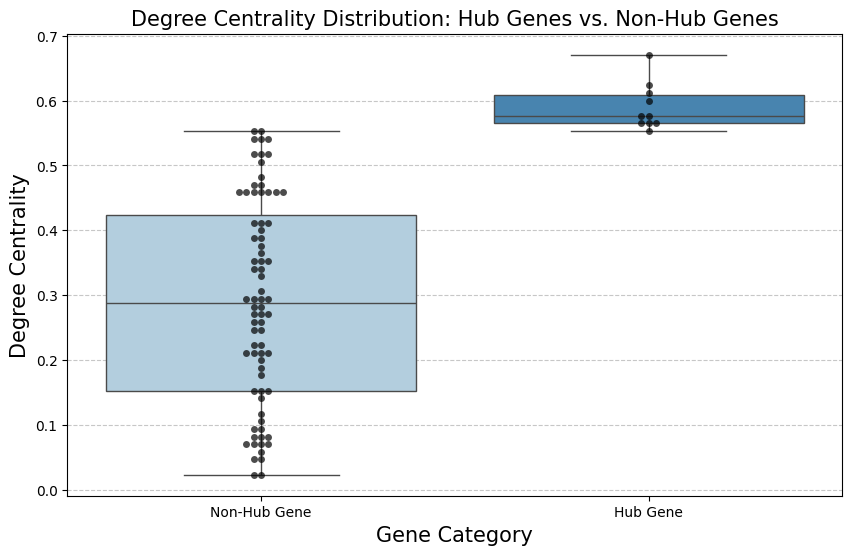

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert degree_df Series to DataFrame for merging
degree_df_reset = degree_df.reset_index()
degree_df_reset.columns = ['GeneID', 'DegreeCentrality']

# Merge with differentially_expressed_genes to get all differentially expressed genes
# (including those not in top 10 hubs, but still in the correlation network)
centrality_comparison_df = differentially_expressed_genes.merge(
    degree_df_reset.set_index('GeneID'),
    left_index=True,
    right_index=True,
    how='inner'
)

# Categorize genes as 'Hub Gene' or 'Non-Hub Gene'
centrality_comparison_df['GeneCategory'] = 'Non-Hub Gene'
centrality_comparison_df.loc[centrality_comparison_df.index.isin(top_10_hub_gene_ids), 'GeneCategory'] = 'Hub Gene'

print("DataFrame for centrality boxplot prepared (Hub vs Non-Hub). First 5 rows:")
display(centrality_comparison_df.head())

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='GeneCategory', y='DegreeCentrality', data=centrality_comparison_df, palette='Blues', showfliers=False) # Hide outliers from boxplot, changed palette to Blues
sns.swarmplot(x='GeneCategory', y='DegreeCentrality', data=centrality_comparison_df, color='black', alpha=0.7) # Overlay individual points, changed color to black for contrast
plt.title('Degree Centrality Distribution: Hub Genes vs. Non-Hub Genes', fontsize = 15)
plt.xlabel('Gene Category', fontsize = 15)
plt.ylabel('Degree Centrality', fontsize = 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Calculate Gene Significance (GS) for PCOS Trait

Gene Significance (GS) quantifies the association of individual genes with a trait of interest. In this case, our trait is the 'PCOS' condition. I will calculate GS as the absolute Pearson correlation between the expression levels of each gene and the experimental condition (PCOS vs. Control).

To do this, I will:
1.  Map the 'condition' labels ('control', 'PCOS') to numerical values (e.g., 0 and 1).
2.  Calculate the Pearson correlation coefficient between each gene's expression profile and this numerical condition vector.
3.  Take the absolute value of these correlations to represent Gene Significance.

In [36]:
import pandas as pd
import numpy as np

# Ensure clinical_df and ex_matrix_filtered are aligned by sample (index)
# Create a numerical representation of the 'condition' trait
# Assuming 'control' is 0 and 'PCOS' is 1
trait_condition = clinical_df['condition'].map({'control': 0, 'PCOS': 1}).loc[ex_matrix_filtered.index]

# Calculate Gene Significance (GS) for each gene
# This is the absolute Pearson correlation between gene expression and the trait_condition
gene_significance = ex_matrix_filtered.corrwith(trait_condition, method='pearson').abs()

# Convert to DataFrame for better handling and display
gene_significance_df = gene_significance.to_frame(name='GeneSignificance')

print("Gene Significance (GS) for PCOS Trait (top 10 genes by significance):")
display(gene_significance_df.sort_values(by='GeneSignificance', ascending=False).head(10))

# Merge GS with differentially_expressed_genes for comprehensive results
differentially_expressed_genes = differentially_expressed_genes.merge(
    gene_significance_df,
    left_index=True,
    right_index=True,
    how='left'
)

print("\nDifferentially expressed genes with added Gene Significance (first 5 rows):")
display(differentially_expressed_genes.head())

Gene Significance (GS) for PCOS Trait (top 10 genes by significance):


,GeneSignificance
0,
ENSG00000239528.1,0.992105
ENSG00000213058.3,0.981291
ENSG00000214455.4,0.969114
ENSG00000231793.5,0.964283
ENSG00000224114.1,0.962895
ENSG00000204991.11,0.960307
ENSG00000007341.19,0.949751
ENSG00000279453.1,0.948605
ENSG00000242516.2,0.945093



Differentially expressed genes with added Gene Significance (first 5 rows):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol,GeneSignificance
0,,,,,,,,,,
ENSG00000215790.7,384.955023,1.122125,0.281557,3.985422,6.736036e-05,0.018358,1.736170,Upregulated,SLC35E2A,0.870423
ENSG00000158055.16,29.956322,-2.894274,0.573072,-5.050454,4.407623e-07,0.000402,3.395325,Downregulated,GRHL3,0.809371
ENSG00000178965.14,6.376822,-4.002659,1.052922,-3.801477,1.438362e-04,0.033246,1.478258,Downregulated,ERICH3,0.872591
ENSG00000171488.15,382.254173,-1.687147,0.430737,-3.916884,8.970097e-05,0.023070,1.636960,Downregulated,LRRC8C,0.797021
ENSG00000233593.10,41.195160,2.344547,0.564841,4.150808,3.313037e-05,0.012099,1.917243,Upregulated,LINC02609,0.813283


## Weighted Gene Co-expression Network Analysis (WGCNA) - Soft Thresholding

WGCNA aims to find modules (clusters) of highly co-expressed genes. The general steps involve:

1.  **Data Preparation:** Ensuring expression data is normalized and filtered (which we've already done).
2.  **Soft Thresholding Power (β) Selection:** Determine an optimal `β` to construct a scale-free network.
3.  **Adjacency Matrix Construction:** Transform the gene-gene correlation matrix into a weighted adjacency matrix using the selected `β`.
4.  **Topological Overlap Matrix (TOM) Calculation:** Convert the adjacency matrix into a TOM, which measures shared neighborhood between genes.
5.  **Hierarchical Clustering and Module Detection:** Cluster genes based on TOM dissimilarity and cut the dendrogram to define modules.
6.  **Module Eigengene (ME) Calculation:** Summarize gene expression within each module into a single representative profile.
7.  **Module Membership (kME) Calculation:** Quantify how strongly each gene belongs to each module (correlation of gene expression with MEs).
8.  **Module-Trait Relationship Analysis:** Correlate MEs with clinical traits (like PCOS status).

Here, we'll focus on the critical **Soft Thresholding Power Selection** as the initial step.

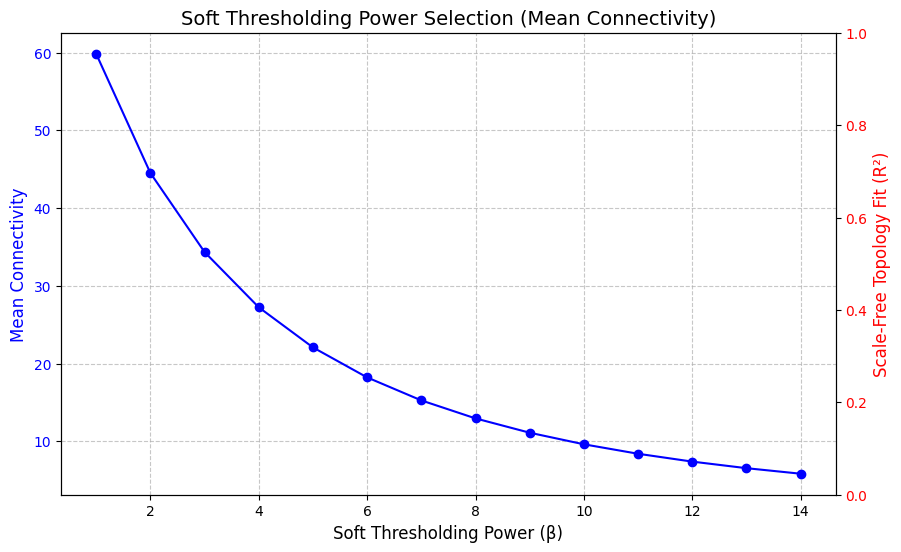

This plot shows how the mean connectivity of the network changes as we increase the soft-thresholding power (β).
In a full WGCNA, one typically aims for the smallest β that results in a scale-free topology fit R² greater than 0.8 or 0.9 (represented by the red line, which is currently a placeholder). You also want to ensure mean connectivity remains reasonably low to avoid overly dense networks.
Based on this plot, you would visually select a beta where the mean connectivity starts to level off or drops significantly, indicating a good balance between network density and topology.


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure ex_matrix_filtered is used (samples x genes) for correlation calculation
# correlation_matrix is already computed and has genes as rows/columns.

# 1. Calculate pairwise correlations (absolute value)
# We'll use the absolute value of the already computed correlation_matrix.
abs_cor_matrix = np.abs(correlation_matrix)

# Fill diagonal with 0 to remove self-loops for network construction
np.fill_diagonal(abs_cor_matrix.values, 0)

# Define a range of soft-thresholding powers (beta values)
powers = range(1, 15) # A common range for testing

# Store results
mean_connectivities = []
sft_r_squared_values = [] # Placeholder for a more complex calculation

for beta in powers:
    # Calculate adjacency matrix: A_ij = |cor(i,j)|^beta
    adj_matrix = abs_cor_matrix ** beta

    # Calculate connectivity (k) for each gene: sum of connections in adjacency matrix
    connectivity = adj_matrix.sum(axis=1)

    mean_connectivities.append(connectivity.mean())

    # --- Placeholder for Scale-Free Topology Fit (R²) ----
    # A proper R² calculation involves fitting a linear model to the log-log scale
    # of the connectivity distribution. This is a complex statistical step often
    # handled by specialized WGCNA software (like the R package).
    # For this demonstration, we'll focus on mean connectivity.
    sft_r_squared_values.append(np.nan) # Fill with NaN for now

# Plotting mean connectivity
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(powers, mean_connectivities, 'o-', color='blue')
ax1.set_xlabel('Soft Thresholding Power (β)', fontsize=12)
ax1.set_ylabel('Mean Connectivity', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)

# Add a second y-axis as a visual placeholder for R^2, even if it's NaN
ax2 = ax1.twinx()
ax2.plot(powers, sft_r_squared_values, 'x-', color='red', alpha=0.5)
ax2.set_ylabel('Scale-Free Topology Fit (R²)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 1])

plt.title('Soft Thresholding Power Selection (Mean Connectivity)', fontsize=14)
plt.show()

print("This plot shows how the mean connectivity of the network changes as we increase the soft-thresholding power (β).")
print("In a full WGCNA, one typically aims for the smallest β that results in a scale-free topology fit R² greater than 0.8 or 0.9 (represented by the red line, which is currently a placeholder). You also want to ensure mean connectivity remains reasonably low to avoid overly dense networks.")
print("Based on this plot, you would visually select a beta where the mean connectivity starts to level off or drops significantly, indicating a good balance between network density and topology.")

## Adjacency Matrix Construction

Now that we've visually assessed the soft-thresholding powers, we'll select a β value and use it to construct the adjacency matrix. This matrix quantifies the connection strength between gene pairs, forming the basis of our co-expression network. A β value of `6` is chosen here as a balance point from the mean connectivity plot, where the network starts to become less dense without losing too much structure.

In [40]:
import numpy as np
import pandas as pd

# Choose the soft-thresholding power (beta) based on the plot
# A beta of 6 is chosen as an example where mean connectivity starts to level off.
chosen_beta = 6

# Ensure abs_cor_matrix is available from previous step
# If it's not, you'd recompute: abs_cor_matrix = np.abs(correlation_matrix)
# Fill diagonal with 0 to remove self-loops
np.fill_diagonal(abs_cor_matrix.values, 0)

# Calculate the adjacency matrix: A_ij = |cor(i,j)|^beta
adjacency_matrix = abs_cor_matrix ** chosen_beta

print(f"Adjacency Matrix constructed using beta = {chosen_beta}. First 5 rows and columns:")
display(adjacency_matrix.head())

Adjacency Matrix constructed using beta = 6. First 5 rows and columns:


0,ENSG00000215790.7,ENSG00000158055.16,ENSG00000178965.14,ENSG00000171488.15,ENSG00000233593.10,ENSG00000007341.19,ENSG00000277147.6,ENSG00000143603.19,ENSG00000213058.3,ENSG00000224114.1,...,ENSG00000086717.18,ENSG00000044446.12,ENSG00000124486.13,ENSG00000215301.11,ENSG00000147044.22,ENSG00000133142.17,ENSG00000157502.13,ENSG00000089682.16,ENSG00000101938.15,ENSG00000203952.9
0,,,,,,,,,,,,,,,,,,,,,
ENSG00000215790.7,0.000000,0.042526,0.072599,0.071318,0.425161,0.467396,0.047733,0.202912,0.309353,0.225957,...,0.113623,0.175371,0.294576,0.089286,0.192629,0.109689,0.027219,0.174315,0.069836,0.334389
ENSG00000158055.16,0.042526,0.000000,0.856049,0.263518,0.091645,0.175405,0.284952,0.018680,0.375334,0.310404,...,0.503445,0.053248,0.350056,0.285469,0.448689,0.472275,0.118932,0.036535,0.172253,0.073853
ENSG00000178965.14,0.072599,0.856049,0.000000,0.239967,0.147463,0.245508,0.408834,0.092896,0.582767,0.551414,...,0.511825,0.107890,0.348598,0.358808,0.504748,0.609525,0.243939,0.077913,0.286078,0.117245
ENSG00000171488.15,0.071318,0.263518,0.239967,0.000000,0.114686,0.294501,0.296887,0.013804,0.142907,0.103928,...,0.790754,0.289952,0.334665,0.124186,0.159618,0.177810,0.095817,0.176055,0.023338,0.331957
ENSG00000233593.10,0.425161,0.091645,0.147463,0.114686,0.000000,0.358250,0.176816,0.149239,0.231306,0.235664,...,0.190264,0.136442,0.216668,0.055208,0.157174,0.200804,0.100093,0.045246,0.043648,0.121660


## Topological Overlap Matrix (TOM) Calculation

To identify modules of co-expressed genes, we need to transform the adjacency matrix into a Topological Overlap Matrix (TOM). The TOM quantifies the degree of 'topological overlap' between two genes, meaning how much they share the same neighbors in the network, taking into account both direct and indirect connections. This measure is more robust to spurious connections than direct adjacency.

The formula for the Topological Overlap between two nodes _i_ and _j_ is given by:

$$TOM_{ij} = \frac{L_{ij} + A_{ij}}{min(k_i, k_j) + 1 - A_{ij}}$$

Where:
*   $A_{ij}$ is the adjacency between gene _i_ and gene _j_.
*   $L_{ij}$ is the number of neighbors that gene _i_ and gene _j_ share (sum of products of adjacencies of their common neighbors).
*   $k_i$ and $k_j$ are the connectivities (sum of adjacencies) of gene _i_ and gene _j_, respectively.

In [42]:
import numpy as np
import pandas as pd

# Ensure adjacency_matrix is available (from the previous step)

# Calculate connectivity (k) for each gene
k = adjacency_matrix.sum(axis=1)

# Calculate L_ij: sum of products of adjacencies of their common neighbors
# L_ij = (A * A). This matrix multiplication effectively calculates shared neighbors.
L_matrix = np.dot(adjacency_matrix, adjacency_matrix)

# Get the minimum connectivity between each pair of genes
# Convert k to a numpy array to ensure compatibility with np.minimum.outer
k_array = k.to_numpy()
k_min_matrix = pd.DataFrame(np.minimum.outer(k_array, k_array), index=adjacency_matrix.index, columns=adjacency_matrix.columns)

# Calculate TOM
# TOM_ij = (L_ij + A_ij) / (min(k_i, k_j) + 1 - A_ij)
# Add a small epsilon to the denominator to prevent division by zero if min(k_i, k_j) + 1 - A_ij is zero.
epsilon = 1e-9 # A small constant
topological_overlap_matrix = (L_matrix + adjacency_matrix) / (k_min_matrix + 1 - adjacency_matrix + epsilon)

# Ensure diagonal is 1 (a gene has full topological overlap with itself)
np.fill_diagonal(topological_overlap_matrix.values, 1)

print("Topological Overlap Matrix (TOM) calculated. First 5 rows and columns:")
display(topological_overlap_matrix.head())

Topological Overlap Matrix (TOM) calculated. First 5 rows and columns:


0,ENSG00000215790.7,ENSG00000158055.16,ENSG00000178965.14,ENSG00000171488.15,ENSG00000233593.10,ENSG00000007341.19,ENSG00000277147.6,ENSG00000143603.19,ENSG00000213058.3,ENSG00000224114.1,...,ENSG00000086717.18,ENSG00000044446.12,ENSG00000124486.13,ENSG00000215301.11,ENSG00000147044.22,ENSG00000133142.17,ENSG00000157502.13,ENSG00000089682.16,ENSG00000101938.15,ENSG00000203952.9
0,,,,,,,,,,,,,,,,,,,,,
ENSG00000215790.7,1.000000,0.166077,0.214952,0.183345,0.281271,0.394381,0.252493,0.242740,0.416566,0.377384,...,0.280767,0.329999,0.350335,0.210652,0.291855,0.273059,0.204587,0.281888,0.183852,0.376081
ENSG00000158055.16,0.166077,1.000000,0.395375,0.236448,0.177972,0.330004,0.374393,0.165101,0.460018,0.431829,...,0.395748,0.274799,0.372266,0.275577,0.366549,0.397319,0.290485,0.211277,0.235417,0.285229
ENSG00000178965.14,0.214952,0.395375,1.000000,0.286758,0.249178,0.341409,0.393561,0.219917,0.474426,0.455438,...,0.372059,0.299406,0.352163,0.280288,0.349636,0.403084,0.329169,0.226808,0.268944,0.297264
ENSG00000171488.15,0.183345,0.236448,0.286758,1.000000,0.182680,0.346234,0.358442,0.156017,0.375602,0.347362,...,0.424799,0.363930,0.369606,0.232594,0.299105,0.307880,0.268080,0.282325,0.170463,0.374260
ENSG00000233593.10,0.281271,0.177972,0.249178,0.182680,1.000000,0.396385,0.330090,0.237553,0.417516,0.400130,...,0.304227,0.315768,0.328603,0.187214,0.278660,0.329339,0.276219,0.222469,0.168544,0.320016


## Hierarchical Clustering and Module Detection

With the Topological Overlap Matrix (TOM) calculated, we can now proceed to hierarchical clustering. This step groups genes into modules based on the dissimilarity derived from the TOM. After clustering, a dynamic tree cut algorithm will be used to identify distinct gene modules.

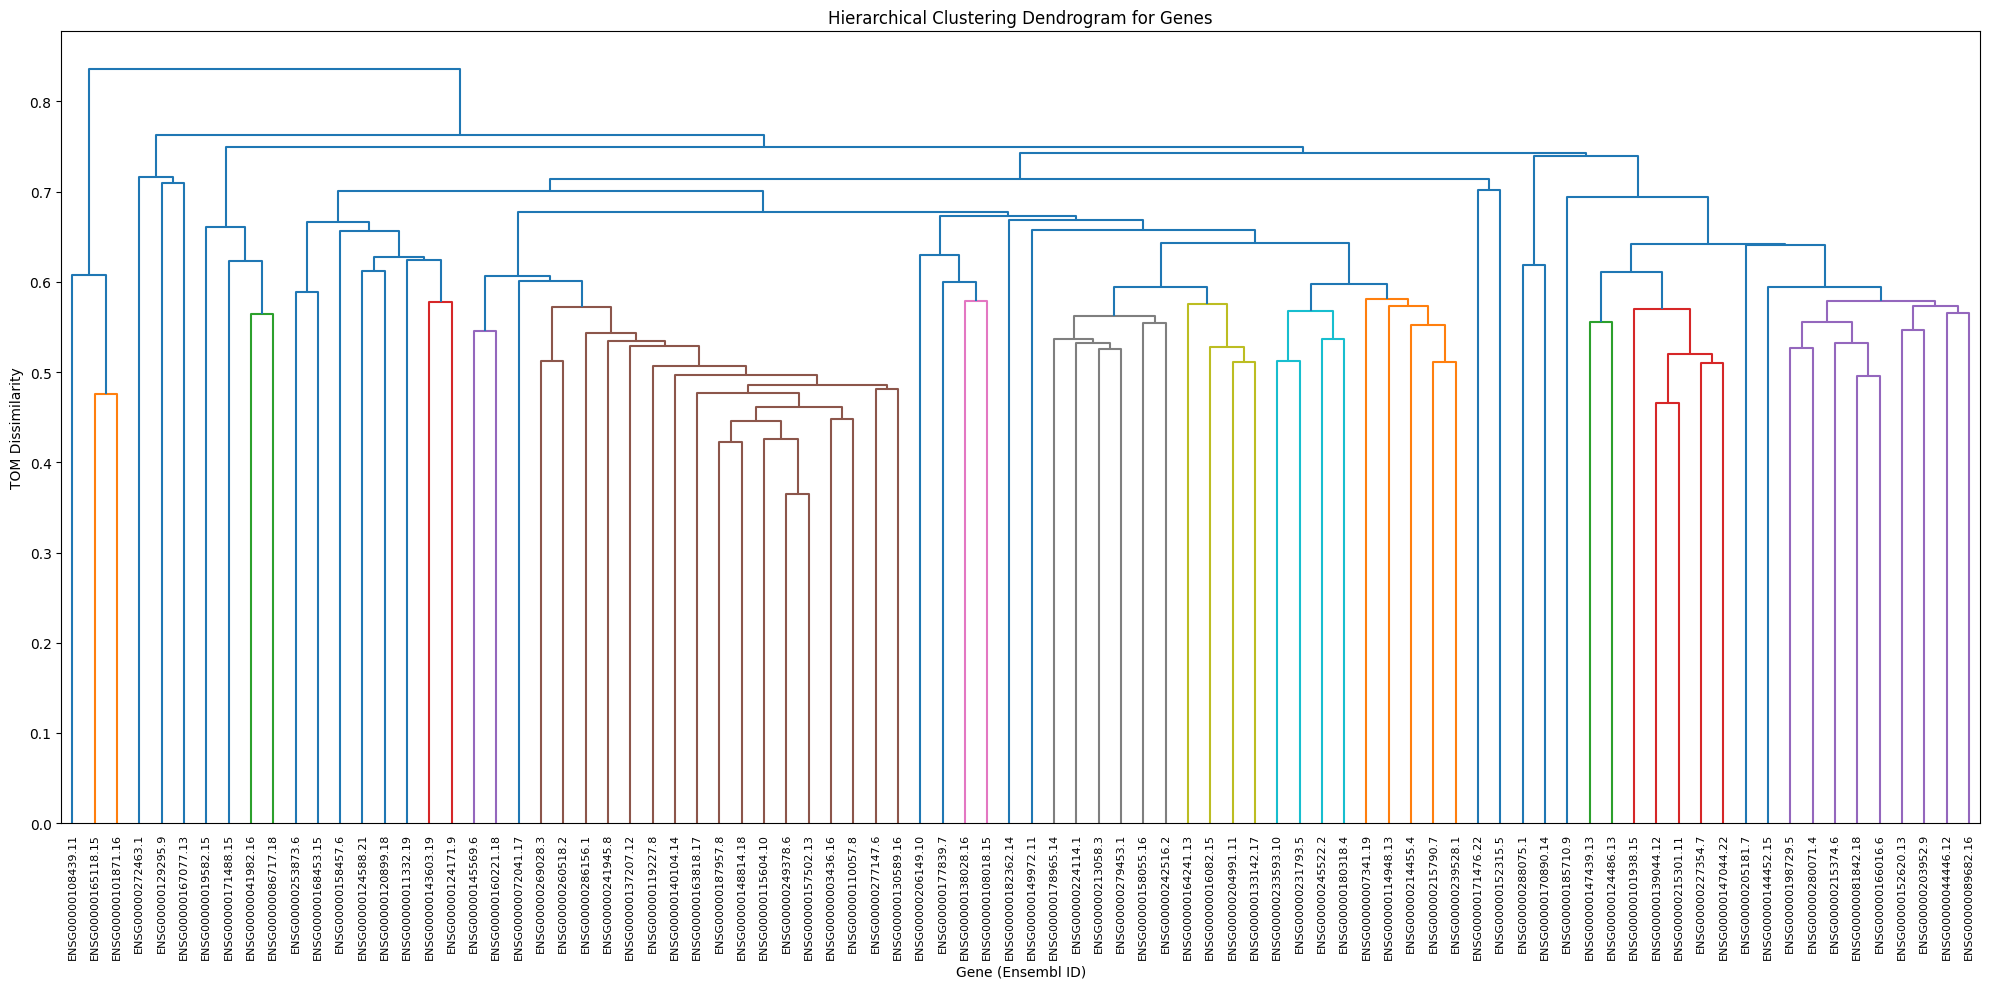

Hierarchical clustering performed and dendrogram plotted. The next step would be to cut the dendrogram to define modules.


In [43]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate TOM Dissimilarity
# TOM is a similarity matrix (values close to 1 mean high similarity).
# Dissimilarity is 1 - TOM.
TOM_dissimilarity = 1 - topological_overlap_matrix

# 2. Perform Hierarchical Clustering
# We use the 'average' linkage method, which is common in WGCNA.
# The clustering function expects a condensed distance matrix.
# np.array(TOM_dissimilarity) ensures it's a NumPy array, then [np.triu_indices(TOM_dissimilarity.shape[0], k=1)]
# extracts the upper triangle (excluding diagonal) to form a condensed distance matrix.
linkage_matrix = sch.linkage(TOM_dissimilarity.values[np.triu_indices(TOM_dissimilarity.shape[0], k=1)], method='average')

# 3. Plot Dendrogram
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram for Genes')
plt.xlabel('Gene (Ensembl ID)')
plt.ylabel('TOM Dissimilarity')

# You can choose to cut the dendrogram at a certain height to get modules.
# For now, let's just plot it.
dendro = sch.dendrogram(
    linkage_matrix,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    labels=topological_overlap_matrix.index.tolist()
)
plt.tight_layout()
plt.show()

print("Hierarchical clustering performed and dendrogram plotted. The next step would be to cut the dendrogram to define modules.")

# Note: Dynamic Tree Cut (e.g., from R's WGCNA package) is often used for module detection.
# For a pure Python implementation, you might use fcluster with a more sophisticated height determination
# or a different clustering algorithm that supports automatic module detection.